# Proyecto Final - Machine Learning II

## Pronóstico de Ocupación por Barrio - Barcelona

**Problema:** 7 - Pronóstico de ocupación por barrio  
**Ciudad:** Barcelona  
**Fuente:** Inside Airbnb  
**Variable objetivo:** `occupancy_rate`  
**Métrica principal:** MAE  
**Validador:** TimeSeriesSplit

**Integrantes:**
 - Karina Bosquez
 - Joshua Campos
 - Jose Atencio


---
## 1. Configuración, carga y exploración

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np

# Semilla para reproducibilidad
SEED = 42



### Carga de Datos

In [3]:
# Rutas relativas del proyecto
PROJECT_PATH = Path("..")
RAW_PATH = PROJECT_PATH / "data" / "raw"
PROCESSED_PATH = PROJECT_PATH / "data" / "processed"
MODELS_PATH = PROJECT_PATH / "models"
FIGURES_PATH = PROJECT_PATH / "figures"

#print("RAW:", RAW_PATH.resolve())

# Cragamos nuestros Datos dese los archivos fuentes.abs

calendar = pd.read_csv(RAW_PATH / "calendar.csv.gz")
listings = pd.read_csv(RAW_PATH / "listings.csv.gz")

print("Archivos cargados correctamente.")

Archivos cargados correctamente.


### Exploración y calidad de los datos

In [4]:
# Verificamos cantidad de Registros  y columnas de cada archivo.

print("CALENDAR")
print("Filas:", calendar.shape[0])
print("Columnas:", calendar.shape[1])

print("\nLISTINGS")
print("Filas:", listings.shape[0])
print("Columnas:", listings.shape[1])

CALENDAR
Filas: 5623190
Columnas: 5

LISTINGS
Filas: 15293
Columnas: 90


In [5]:
# Visualizamos las columnas en cada archivo

print("***** COLUMNAS DE CALENDAR:***** ")
print(calendar.columns.tolist())

print("\n***** COLUMNAS DE LISTINGS:***** ")
print(listings.columns.tolist())

***** COLUMNAS DE CALENDAR:***** 
['listing_id', 'date', 'available', 'minimum_nights', 'maximum_nights']

***** COLUMNAS DE LISTINGS:***** 
['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_profile_id', 'host_profile_url', 'host_name', 'host_since', 'hosts_time_as_user_years', 'hosts_time_as_user_months', 'hosts_time_as_host_years', 'hosts_time_as_host_months', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'pric


#### - Informacion General de Calendar


In [6]:

print("\nTipos de datos:")
print(calendar.dtypes)

print("\nValores nulos:")
print(calendar.isnull().sum())

print("\nValores únicos de 'available':")
print(calendar["available"].value_counts(dropna=False))

print("\nNúmero de alojamientos únicos:")
print(calendar["listing_id"].nunique())

print("\nRango de fechas:")
print("Desde:", calendar["date"].min())
print("Hasta:", calendar["date"].max())

print("\nFilas duplicadas:")
print(calendar.duplicated().sum())

print("\nDuplicados listing_id + date:")
print(calendar.duplicated(subset=["listing_id", "date"]).sum())


Tipos de datos:
listing_id         int64
date              object
available         object
minimum_nights     int64
maximum_nights     int64
dtype: object

Valores nulos:
listing_id        0
date              0
available         0
minimum_nights    0
maximum_nights    0
dtype: int64

Valores únicos de 'available':
available
t    3281038
f    2342152
Name: count, dtype: int64

Número de alojamientos únicos:
15406

Rango de fechas:
Desde: 2026-06-24
Hasta: 2027-07-02

Filas duplicadas:
0

Duplicados listing_id + date:
0



#### - Informacion General de Listings


In [7]:

print("\nFilas:", len(listings))
print("IDs únicos:", listings["id"].nunique())
print("IDs duplicados:", listings["id"].duplicated().sum())
print("IDs nulos:", listings["id"].isnull().sum())



Filas: 15293
IDs únicos: 15293
IDs duplicados: 0
IDs nulos: 0


## 2. Validación Calendar–Listings y calidad de datos

In [8]:

calendar_ids = set(calendar["listing_id"].unique())
listings_ids = set(listings["id"].unique())

solo_calendar = calendar_ids - listings_ids
solo_listings = listings_ids - calendar_ids
comunes = calendar_ids & listings_ids


print("\nIDs en Calendar:", len(calendar_ids))
print("IDs en Listings:", len(listings_ids))
print("IDs comunes:", len(comunes))
print("Solo en Calendar:", len(solo_calendar))
print("Solo en Listings:", len(solo_listings))


IDs en Calendar: 15406
IDs en Listings: 15293
IDs comunes: 15293
Solo en Calendar: 113
Solo en Listings: 0




#### - Impacto de IDs en Calendar sin detalles en Listings

In [9]:
filas_sin_listing = calendar[
    calendar["listing_id"].isin(solo_calendar)
]
print("\nAlojamientos afectados:",
      filas_sin_listing["listing_id"].nunique())

print("Filas afectadas:", len(filas_sin_listing))

print("Porcentaje de filas afectadas:", round(len(filas_sin_listing) / len(calendar) * 100, 4), "%")


Alojamientos afectados: 113
Filas afectadas: 41245
Porcentaje de filas afectadas: 0.7335 %


## 3. Selección de variable geográfica

In [10]:

columnas_geo = [
    "id",
    "neighbourhood",
    "neighbourhood_cleansed",
    "neighbourhood_group_cleansed"
]

for col in columnas_geo:
    print(f"\n{col}")
    print("Nulos:", listings[col].isnull().sum())
    print("Valores únicos:", listings[col].nunique())



id
Nulos: 0
Valores únicos: 15293

neighbourhood
Nulos: 15293
Valores únicos: 0

neighbourhood_cleansed
Nulos: 0
Valores únicos: 69

neighbourhood_group_cleansed
Nulos: 0
Valores únicos: 10


#### Decsion variables
**neighbourhood**                    → descartada, porque es 100% valores nulos

**neighbourhood_cleansed**           → seleccionada, porque es la variable a analizar

**neighbourhood_group_cleansed**     → conservada como nivel superior, para agurpar la variable seleccionada

#### - Alojamiento por neighbourhood_cleansed

In [11]:
print ("\n")
barrios = (
    listings["neighbourhood_cleansed"]
    .value_counts()
    .sort_values(ascending=False)
)

print(barrios)



neighbourhood_cleansed
la Dreta de l'Eixample                   2145
el Raval                                 1031
Sant Pere, Santa Caterina i la Ribera     925
la Vila de Gràcia                         924
la Sagrada Família                        910
                                         ... 
la Marina del Prat Vermell                  3
la Trinitat Vella                           3
la Trinitat Nova                            3
Torre Baró                                  1
Ciutat Meridiana                            1
Name: count, Length: 69, dtype: int64


#### - Alojamiento por neighbourhood_group_cleansed

In [12]:
print ("\n")

distritos = (
    listings["neighbourhood_group_cleansed"]
    .value_counts()
    .sort_values(ascending=False)
)

print(distritos)



neighbourhood_group_cleansed
Eixample               5835
Ciutat Vella           3247
Sants-Montjuïc         1448
Sant Martí             1436
Gràcia                 1366
Sarrià-Sant Gervasi     888
Horta-Guinardó          358
Les Corts               327
Sant Andreu             225
Nou Barris              163
Name: count, dtype: int64


In [13]:


print("\n=== TOP 20: neighbourhood_cleansed ===")
print(listings["neighbourhood_cleansed"].value_counts().head(20))

print("\n=== neighbourhood_group_cleansed ===")
print(listings["neighbourhood_group_cleansed"].value_counts())


=== TOP 20: neighbourhood_cleansed ===
neighbourhood_cleansed
la Dreta de l'Eixample                   2145
el Raval                                 1031
Sant Pere, Santa Caterina i la Ribera     925
la Vila de Gràcia                         924
la Sagrada Família                        910
el Barri Gòtic                            881
l'Antiga Esquerra de l'Eixample           850
Sant Antoni                               846
la Nova Esquerra de l'Eixample            660
el Poble Sec                              650
Sant Gervasi - Galvany                    448
el Poblenou                               437
el Fort Pienc                             424
la Barceloneta                            410
Sants                                     266
el Camp de l'Arpa del Clot                258
el Camp d'en Grassot i Gràcia Nova        257
les Corts                                 229
el Putxet i el Farró                      203
Hostafrancs                               176
Name: count, dtyp

## 4. Construcción del target occupancy_rate (Objetivo)

#### 6.1 Definición de la variable objetivo

La variable objetivo del proyecto será `occupancy_rate`, definida como la proporción
de alojamientos marcados como no disponibles (`available = f`) para cada barrio y fecha.

La unidad de observación será la combinación **fecha × barrio**, utilizando
neighbourhood_cleansed como variable geográfica.

occupancy_rate se interpretará como una estimación de la ocupación basada en la
disponibilidad publicada en el calendario. Un alojamiento no disponible no implica
necesariamente una reserva, ya que una fecha también puede haber sido bloqueada por
el anfitrión.

##  5. Filtrado de barrios y preparación del dataset

In [14]:
#Validar el tamaño de disponibilidad total de los barrios para identificar si hay barrios con muy poca ocupacion
#que nos pueda sesgar los resutados
conteo_barrios = (
    listings["neighbourhood_cleansed"]
    .value_counts()
    .sort_values()
)

print("=== DISTRIBUCIÓN DE LISTINGS POR BARRIO ===")

print("Número de barrios:", len(conteo_barrios))
print("Mínimo de listings:", conteo_barrios.min())
print("Máximo de listings:", conteo_barrios.max())
print("Mediana:", conteo_barrios.median())

print("\n=== 15 BARRIOS CON MENOS LISTINGS ===")
print(conteo_barrios.head(15))

=== DISTRIBUCIÓN DE LISTINGS POR BARRIO ===
Número de barrios: 69
Mínimo de listings: 1
Máximo de listings: 2145
Mediana: 72.0

=== 15 BARRIOS CON MENOS LISTINGS ===
neighbourhood_cleansed
Ciutat Meridiana               1
Torre Baró                     1
la Marina del Prat Vermell     3
la Trinitat Vella              3
la Trinitat Nova               3
Verdun                         4
la Clota                       4
Sant Genís dels Agudells       5
Montbau                        6
la Vall d'Hebron               7
el Bon Pastor                  8
Horta                         12
les Roquetes                  13
la Guineueta                  13
la Teixonera                  13
Name: count, dtype: int64


In [15]:
umbrales = [1, 5, 10, 20, 30, 50, 100]

resultados_umbral = []

for minimo in umbrales:

    barrios_validos = conteo_barrios[
        conteo_barrios >= minimo
    ]

    listings_incluidos = barrios_validos.sum()

    resultados_umbral.append({
        "minimo_listings": minimo,
        "barrios conservados": len(barrios_validos),
        "cobertura": listings_incluidos / len(listings) * 100
    })

df_umbrales = pd.DataFrame(resultados_umbral)

df_umbrales

,minimo_listings,barrios conservados,cobertura
0,1,69,100.000000
1,5,62,99.875760
2,10,58,99.705748
3,20,51,99.051854
4,30,47,98.371804
5,50,42,97.201334
6,100,26,89.557314


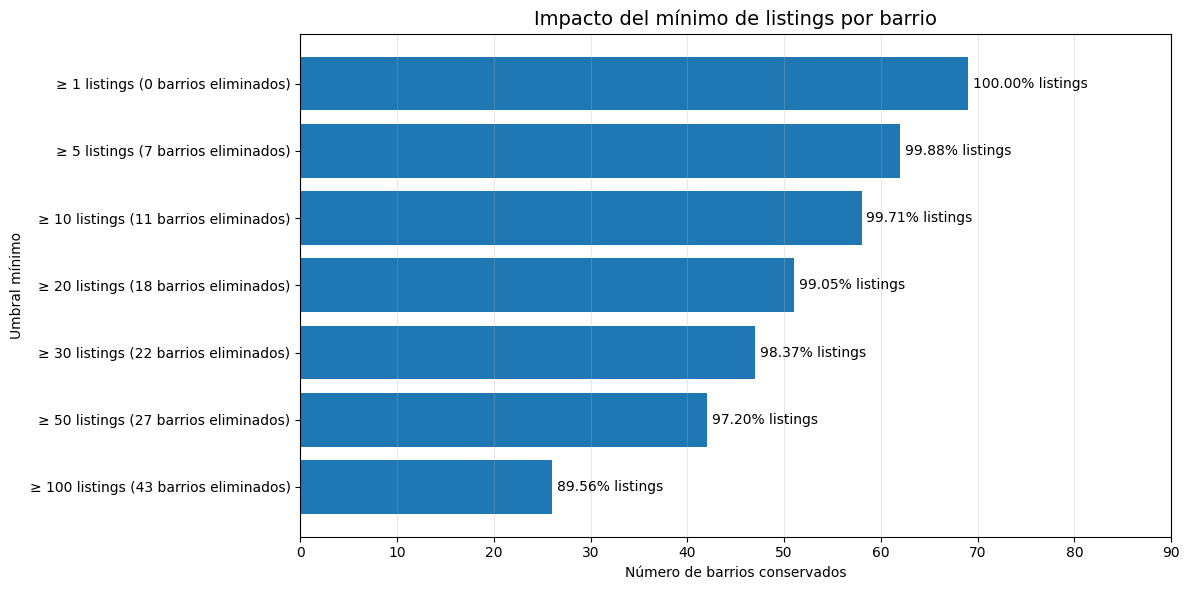

In [16]:
import matplotlib.pyplot as plt

total_barrios = 69

df_grafico = df_umbrales.sort_values(
    "minimo_listings",
    ascending=False
).copy()

# Calcular barrios eliminados
df_grafico["barrios_eliminados"] = (
    total_barrios - df_grafico["barrios conservados"]
)

# Crear etiqueta del eje Y
df_grafico["etiqueta"] = (
    "≥ " + df_grafico["minimo_listings"].astype(str)
    + " listings ("
    + df_grafico["barrios_eliminados"].astype(str)
    + " barrios eliminados)"
)

# Crear gráfico
plt.figure(figsize=(12, 6))

bars = plt.barh(
    df_grafico["etiqueta"],
    df_grafico["barrios conservados"]
)

# Mostrar porcentaje de listings conservados
for bar, cobertura in zip(bars, df_grafico["cobertura"]):
    plt.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{cobertura:.2f}% listings",
        va="center",
        fontsize=10
    )

plt.title("Impacto del mínimo de listings por barrio", fontsize=14)
plt.xlabel("Número de barrios conservados")
plt.ylabel("Umbral mínimo")

plt.xlim(0, 90)
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

<br>


####  Preparacion del Dataset para trabajar

In [17]:
# Crear copia de trabajo para no modificar el dataset original
calendar_work = calendar.copy()

# Convertir fecha a formato datetime
calendar_work["date"] = pd.to_datetime(
    calendar_work["date"]
)

# Transformar disponibilidad:
# t = disponible     -> 0
# f = no disponible  -> 1
calendar_work["unavailable"] = (
    calendar_work["available"]
    .map({"t": 0, "f": 1})
)

calendar_work[
    ["listing_id", "date", "available", "unavailable"]
].head(10)

,listing_id,date,available,unavailable
0,18674,2026-06-25,f,1
1,18674,2026-06-26,f,1
2,18674,2026-06-27,f,1
3,18674,2026-06-28,t,0
4,18674,2026-06-29,f,1
5,18674,2026-06-30,f,1
6,18674,2026-07-01,f,1
7,18674,2026-07-02,f,1
8,18674,2026-07-03,f,1
9,18674,2026-07-04,f,1


In [18]:
#VAlidacion de como quedo la dat

print("\nValores originales de available:")
print(calendar_work["available"].value_counts(dropna=False))

print("\nValores generados de unavailable:")
print(calendar_work["unavailable"].value_counts(dropna=False))

print("\nNulos generados:")
print(calendar_work["unavailable"].isnull().sum())

print("\nTipo de date:")
print(calendar_work["date"].dtype)

print("\nRango temporal:")
print(
    calendar_work["date"].min(),
    "→",
    calendar_work["date"].max()
)


Valores originales de available:
available
t    3281038
f    2342152
Name: count, dtype: int64

Valores generados de unavailable:
unavailable
0    3281038
1    2342152
Name: count, dtype: int64

Nulos generados:
0

Tipo de date:
datetime64[ns]

Rango temporal:
2026-06-24 00:00:00 → 2027-07-02 00:00:00



## 6. Integración Calendar + información geográfica


In [19]:
listings_geo = listings[
    [
        "id",
        "neighbourhood_cleansed",
        "neighbourhood_group_cleansed"
    ]
].copy()

listings_geo.head()

,id,neighbourhood_cleansed,neighbourhood_group_cleansed
0,18674,la Sagrada Família,Eixample
1,23197,el Besòs i el Maresme,Sant Martí
2,34981,el Barri Gòtic,Ciutat Vella
3,36763,la Barceloneta,Ciutat Vella
4,40983,la Dreta de l'Eixample,Eixample


In [20]:
validacion_geo = (
    listings_geo
    .groupby("neighbourhood_cleansed")
    ["neighbourhood_group_cleansed"]
    .nunique()
)



print("Máximo número de grupos asociados a un barrio:")
print(validacion_geo.max())

print("\nBarrios asociados a más de un grupo:")
print(validacion_geo[validacion_geo > 1])

Máximo número de grupos asociados a un barrio:
1

Barrios asociados a más de un grupo:
Series([], Name: neighbourhood_group_cleansed, dtype: int64)


In [21]:
# Hacemos la integracion.
calendar_geo = calendar_work.merge(
    listings_geo,
    left_on="listing_id",
    right_on="id",
    how="inner",
    validate="many_to_one"
)

print("\nFilas calendar original:", len(calendar_work))
print("Filas después del merge:", len(calendar_geo))
print("Filas eliminadas:", len(calendar_work) - len(calendar_geo))

print("\nListings únicos:")
print(calendar_geo["listing_id"].nunique())

print("\nNulos en barrio:")
print(calendar_geo["neighbourhood_cleansed"].isnull().sum())

print("\nNulos en grupo:")
print(calendar_geo["neighbourhood_group_cleansed"].isnull().sum())

print("\nDuplicados listing-fecha:")
print(
    calendar_geo.duplicated(
        subset=["listing_id", "date"]
    ).sum()
)


Filas calendar original: 5623190
Filas después del merge: 5581945
Filas eliminadas: 41245

Listings únicos:
15293

Nulos en barrio:
0

Nulos en grupo:
0

Duplicados listing-fecha:
0


In [22]:
daily_neighbourhood = (
    calendar_geo
    .groupby(
        [
            "date",
            "neighbourhood_group_cleansed",
            "neighbourhood_cleansed"
        ],
        as_index=False
    )
    .agg(
        occupancy_rate=("unavailable", "mean"),
        n_listings=("listing_id", "nunique")
    )
)

daily_neighbourhood.head(10)

,date,neighbourhood_group_cleansed,neighbourhood_cleansed,occupancy_rate,n_listings
0,2026-06-24,Ciutat Vella,"Sant Pere, Santa Caterina i la Ribera",0.900000,90
1,2026-06-24,Ciutat Vella,el Barri Gòtic,1.000000,24
2,2026-06-24,Ciutat Vella,el Raval,1.000000,12
3,2026-06-24,Ciutat Vella,la Barceloneta,0.944444,54
4,2026-06-24,Eixample,Sant Antoni,1.000000,3
5,2026-06-24,Eixample,el Fort Pienc,0.972603,73
6,2026-06-24,Eixample,l'Antiga Esquerra de l'Eixample,0.913043,69
7,2026-06-24,Eixample,la Dreta de l'Eixample,0.910112,89
8,2026-06-24,Eixample,la Nova Esquerra de l'Eixample,0.771429,140
9,2026-06-24,Eixample,la Sagrada Família,0.840909,44


In [23]:
print("=== VALIDACIÓN DE OCCUPANCY_RATE ===")

print("\nDimensiones:")
print(daily_neighbourhood.shape)

print("\nNúmero de barrios:")
print(
    daily_neighbourhood["neighbourhood_cleansed"].nunique()
)

print("\nNúmero de fechas:")
print(
    daily_neighbourhood["date"].nunique()
)

print("\nRango temporal:")
print(
    daily_neighbourhood["date"].min(),
    "→",
    daily_neighbourhood["date"].max()
)

print("\nRango de occupancy_rate:")
print(
    daily_neighbourhood["occupancy_rate"].min(),
    "→",
    daily_neighbourhood["occupancy_rate"].max()
)

print("\nNulos en occupancy_rate:")
print(
    daily_neighbourhood["occupancy_rate"].isnull().sum()
)

print("\nListings por observación barrio-fecha:")
print(
    daily_neighbourhood["n_listings"].describe()
)

print("\nDuplicados fecha-barrio:")
print(
    daily_neighbourhood.duplicated(
        subset=["date", "neighbourhood_cleansed"]
    ).sum()
)

=== VALIDACIÓN DE OCCUPANCY_RATE ===

Dimensiones:
(25749, 5)

Número de barrios:
69

Número de fechas:
374

Rango temporal:
2026-06-24 00:00:00 → 2027-07-02 00:00:00

Rango de occupancy_rate:
0.0 → 1.0

Nulos en occupancy_rate:
0

Listings por observación barrio-fecha:
count    25749.000000
mean       216.782982
std        360.331446
min          1.000000
25%         16.000000
50%         70.000000
75%        229.000000
max       2145.000000
Name: n_listings, dtype: float64

Duplicados fecha-barrio:
0


In [24]:
cobertura_barrios = (
    daily_neighbourhood
    .groupby("neighbourhood_cleansed")
    .agg(
        n_fechas=("date", "nunique"),
        fecha_inicio=("date", "min"),
        fecha_fin=("date", "max"),
        n_listings_min=("n_listings", "min"),
        n_listings_max=("n_listings", "max")
    )
    .sort_values("n_fechas")
)

print("=== COBERTURA TEMPORAL POR BARRIO ===")

print(cobertura_barrios.head(15))

print("\nDistribución del número de fechas:")
print(
    cobertura_barrios["n_fechas"]
    .value_counts()
    .sort_index()
)

=== COBERTURA TEMPORAL POR BARRIO ===
                                              n_fechas fecha_inicio  \
neighbourhood_cleansed                                                
Ciutat Meridiana                                   365   2026-06-25   
Torre Baró                                         365   2026-06-25   
la Trinitat Nova                                   365   2026-06-25   
la Clota                                           365   2026-06-25   
les Roquetes                                       365   2026-06-25   
la Marina del Prat Vermell                         366   2026-06-24   
Verdun                                             373   2026-06-25   
la Prosperitat                                     373   2026-06-25   
la Teixonera                                       373   2026-06-24   
la Guineueta                                       373   2026-06-25   
Porta                                              374   2026-06-24   
Provençals del Poblenou                

In [25]:
barrios_incompletos = cobertura_barrios[
    cobertura_barrios["n_fechas"] < 374
]

print("=== BARRIOS CON COBERTURA INCOMPLETA ===")
print(barrios_incompletos)

print(
    "\nNúmero de barrios con menos de 374 fechas:",
    len(barrios_incompletos)
)

=== BARRIOS CON COBERTURA INCOMPLETA ===
                            n_fechas fecha_inicio  fecha_fin  n_listings_min  \
neighbourhood_cleansed                                                         
Ciutat Meridiana                 365   2026-06-25 2027-06-24               1   
Torre Baró                       365   2026-06-25 2027-06-24               1   
la Trinitat Nova                 365   2026-06-25 2027-06-24               3   
la Clota                         365   2026-06-25 2027-06-24               4   
les Roquetes                     365   2026-06-25 2027-06-24              13   
la Marina del Prat Vermell       366   2026-06-24 2027-06-24               1   
Verdun                           373   2026-06-25 2027-07-02               1   
la Prosperitat                   373   2026-06-25 2027-07-02               7   
la Teixonera                     373   2026-06-24 2027-07-01               1   
la Guineueta                     373   2026-06-25 2027-07-02               4   

<br>

#### Vaidacion de Covertura de la data de los alojamientes

In [26]:

# VALIDACIÓN DE COBERTURA DE LISTINGS POR FECHA


coverage_date = (
    calendar_geo
    .groupby("date")["listing_id"]
    .nunique()
    .rename("n_listings_total")
    .reset_index()
)

max_listings = coverage_date["n_listings_total"].max()

coverage_date["coverage_pct"] = (
    coverage_date["n_listings_total"] / max_listings * 100
)

print("=== RESUMEN DE LISTINGS POR FECHA ===")
print(coverage_date["n_listings_total"].describe())

print("\n=== PRIMERAS 10 FECHAS ===")
print(coverage_date.head(10))

print("\n=== ÚLTIMAS 20 FECHAS ===")
print(coverage_date.tail(20))

=== RESUMEN DE LISTINGS POR FECHA ===
count      374.000000
mean     14924.986631
std       2028.225443
min       1738.000000
25%      15293.000000
50%      15293.000000
75%      15293.000000
max      15293.000000
Name: n_listings_total, dtype: float64

=== PRIMERAS 10 FECHAS ===
        date  n_listings_total  coverage_pct
0 2026-06-24              2341     15.307657
1 2026-06-25             13035     85.235075
2 2026-06-26             13035     85.235075
3 2026-06-27             13035     85.235075
4 2026-06-28             13035     85.235075
5 2026-06-29             13035     85.235075
6 2026-06-30             13035     85.235075
7 2026-07-01             13035     85.235075
8 2026-07-02             13555     88.635323
9 2026-07-03             15293    100.000000

=== ÚLTIMAS 20 FECHAS ===
          date  n_listings_total  coverage_pct
354 2027-06-13             15293    100.000000
355 2027-06-14             15293    100.000000
356 2027-06-15             15293    100.000000
357 2027-

## 7. Construcción del dataset final de modelado

In [27]:
# ============================================================
# CONSTRUCCIÓN DEL DATASET CON POBLACIÓN DEFINIDA
# ============================================================

FECHA_INICIO = pd.Timestamp("2026-07-03")
FECHA_FIN = pd.Timestamp("2027-06-23")
MIN_LISTINGS = 10

# Barrios con al menos 10 listings
barrios_seleccionados = conteo_barrios[
    conteo_barrios >= MIN_LISTINGS
].index

# Aplicar ventana temporal + población
df_model = daily_neighbourhood[
    (daily_neighbourhood["date"] >= FECHA_INICIO) &
    (daily_neighbourhood["date"] <= FECHA_FIN) &
    (daily_neighbourhood["neighbourhood_cleansed"].isin(
        barrios_seleccionados
    ))
].copy()

print("=== DATASET PARA MODELADO ===")
print("Dimensiones:", df_model.shape)
print(
    "Barrios:",
    df_model["neighbourhood_cleansed"].nunique()
)
print(
    "Fechas:",
    df_model["date"].nunique()
)
print(
    "Rango temporal:",
    df_model["date"].min(),
    "→",
    df_model["date"].max()
)
print(
    "Nulos occupancy_rate:",
    df_model["occupancy_rate"].isna().sum()
)

print(
    "Duplicados fecha-barrio:",
    df_model.duplicated(
        subset=["date", "neighbourhood_cleansed"]
    ).sum()
)
print("\n=== LISTINGS POR OBSERVACIÓN ===")
print(
    df_model["n_listings"].describe()
)
print("\n=== RANGO DEL TARGET ===")
print(
    df_model["occupancy_rate"].describe()
)

=== DATASET PARA MODELADO ===
Dimensiones: (20648, 5)
Barrios: 58
Fechas: 356
Rango temporal: 2026-07-03 00:00:00 → 2027-06-23 00:00:00
Nulos occupancy_rate: 0
Duplicados fecha-barrio: 0

=== LISTINGS POR OBSERVACIÓN ===
count    20648.000000
mean       262.896552
std        383.532010
min         12.000000
25%         39.000000
50%         82.500000
75%        266.000000
max       2145.000000
Name: n_listings, dtype: float64

=== RANGO DEL TARGET ===
count    20648.000000
mean         0.421199
std          0.127240
min          0.113924
25%          0.333333
50%          0.416667
75%          0.500000
max          1.000000
Name: occupancy_rate, dtype: float64


##  Diccionario de datos del dataset base

DEspues de haber preparado y hacer la agregación, el dataset base para el modelado está compuesto por cinco variables. La unidad de observación corresponde a una combinación de fecha y barrio.

| Variable | Tipo | Descripción | Unidad / Valores |
|---|---|---|---|
| date | Fecha | Fecha correspondiente a la observación de disponibilidad. | Día |
| neighbourhood_group_cleansed | Categórica | Distrito o agrupación geográfica al que pertenece el barrio. | 10 grupos |
| neighbourhood_cleansed | Categórica | Barrio de Barcelona utilizado como unidad geográfica del análisis. | 58 barrios |
| occupancy_rate | Numérica continua | Proporción de listings marcados como no disponibles (`available = f`) para un barrio en una fecha determinada. Se utiliza como proxy de la ocupación estimada. | 0 a 1 |
| n_listings | Numérica discreta | Número de listings observados en el barrio para calcular la tasa de ocupación estimada. | Conteo |

## 8. Partición temporal Development / Test

##### Partición temporal del dataset

dejando los últimos 28 días como conjunto de prueba final.

| Conjunto | Período | Días | Observaciones |
|---|---|---:|---:|
| **Desarrollo** | 03-jul-2026 → 26-may-2027 | 328 | 19,024 |
| **Test final** | 27-may-2027 → 23-jun-2027 | 28 | 1,624 |


El conjunto de **test final** lo tedremso separado durante el desarrollo de los modelos y lo utilizaremos únicamente para la evaluación final.

In [28]:
# PARTICIÓN TEMPORAL: DESARROLLO Y TEST FINAL


HORIZONTE = 28

# Fechas únicas ordenadas
fechas = (
    df_model["date"]
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)

# Últimas 28 fechas para test final
fechas_test = fechas.iloc[-HORIZONTE:]
fechas_desarrollo = fechas.iloc[:-HORIZONTE]

# Separación del dataset
df_dev = df_model[
    df_model["date"].isin(fechas_desarrollo)
].copy()

df_test = df_model[
    df_model["date"].isin(fechas_test)
].copy()

print("PARTICIÓN TEMPORAL")

print("\nDESARROLLO")
print("Desde:", df_dev["date"].min())
print("Hasta:", df_dev["date"].max())
print("Fechas:", df_dev["date"].nunique())
print("Filas:", len(df_dev))
print("Barrios:", df_dev["neighbourhood_cleansed"].nunique())

print("\nTEST FINAL")
print("Desde:", df_test["date"].min())
print("Hasta:", df_test["date"].max())
print("Fechas:", df_test["date"].nunique())
print("Filas:", len(df_test))
print("Barrios:", df_test["neighbourhood_cleansed"].nunique())

print("\nVALIDACIONES")
print("Fechas compartidas:",
      len(set(df_dev["date"]) & set(df_test["date"])))

print("Total filas:",
      len(df_dev) + len(df_test))

print("Total original:",
      len(df_model))

PARTICIÓN TEMPORAL

DESARROLLO
Desde: 2026-07-03 00:00:00
Hasta: 2027-05-26 00:00:00
Fechas: 328
Filas: 19024
Barrios: 58

TEST FINAL
Desde: 2027-05-27 00:00:00
Hasta: 2027-06-23 00:00:00
Fechas: 28
Filas: 1624
Barrios: 58

VALIDACIONES
Fechas compartidas: 0
Total filas: 20648
Total original: 20648


## 9. Partición temporal DEsarrollo / Prueba

La validación se realiza respetando el orden cronológico de los datos.  
En cada iteración, el período de entrenamiento aumenta y la validación se realiza utilizando datos posteriores.

**Fold 1**

`[ ENTRENAMIENTO ──────────────── ][ VALIDACIÓN - 28 días ]`

**Fold 2**

`[ ENTRENAMIENTO ────────────────────────── ][ VALIDACIÓN - 28 días ]`

**Fold 3**

`[ ENTRENAMIENTO ──────────────────────────────────── ][ VALIDACIÓN - 28 días ]`

**Dirección del tiempo →**

A diferencia de una partición aleatoria, este esquema evita utilizar información futura para entrenar un modelo que será evaluado con datos del pasado. De esta manera, la evaluación representa mejor el escenario real de pronóstico.

#### - 3 FOLDS DE 28 DÍAS

In [29]:

# VALIDACIÓN TEMPORAL - 3 FOLDS DE 28 DÍAS


N_FOLDS = 3
VENTANA_VALIDACION = 28

# Fechas disponibles únicamente en desarrollo
fechas_dev = (
    df_dev["date"]
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)

folds_temporales = []

for fold in range(N_FOLDS):

    # Las ventanas de validación se construyen desde el final
    # del período de desarrollo hacia atrás
    fin_val = len(fechas_dev) - fold * VENTANA_VALIDACION
    inicio_val = fin_val - VENTANA_VALIDACION

    fechas_train = fechas_dev.iloc[:inicio_val]
    fechas_val = fechas_dev.iloc[inicio_val:fin_val]

    folds_temporales.append({
        "fold": N_FOLDS - fold,
        "train_inicio": fechas_train.min(),
        "train_fin": fechas_train.max(),
        "train_dias": len(fechas_train),
        "val_inicio": fechas_val.min(),
        "val_fin": fechas_val.max(),
        "val_dias": len(fechas_val)
    })

# Orden cronológico de los folds
folds_temporales = sorted(
    folds_temporales,
    key=lambda x: x["val_inicio"]
)

print(" VALIDACIÓN TEMPORAL \n")

for i, f in enumerate(folds_temporales, start=1):

    print(f"FOLD {i}")

    print(
        f"Entrenamiento: {f['train_inicio'].date()} "
        f"→ {f['train_fin'].date()} "
        f"({f['train_dias']} días)"
    )

    print(
        f"Validación:    {f['val_inicio'].date()} "
        f"→ {f['val_fin'].date()} "
        f"({f['val_dias']} días)"
    )

    print()

 VALIDACIÓN TEMPORAL 

FOLD 1
Entrenamiento: 2026-07-03 → 2027-03-03 (244 días)
Validación:    2027-03-04 → 2027-03-31 (28 días)

FOLD 2
Entrenamiento: 2026-07-03 → 2027-03-31 (272 días)
Validación:    2027-04-01 → 2027-04-28 (28 días)

FOLD 3
Entrenamiento: 2026-07-03 → 2027-04-28 (300 días)
Validación:    2027-04-29 → 2027-05-26 (28 días)



In [30]:

# CREACIÓN DEL LAG SEMANAL (7 DÍAS)


# Ordenar correctamente antes de crear el lag
df_features = (
    df_model
    .sort_values(["neighbourhood_cleansed", "date"])
    .copy()
)

# Ocupación estimada del mismo barrio 7 días antes
df_features["lag_7"] = (
    df_features
    .groupby("neighbourhood_cleansed")["occupancy_rate"]
    .shift(7)
)

print("VALIDACIÓN LAG_7 ")

print("Filas totales:", len(df_features))
print("Nulos en lag_7:", df_features["lag_7"].isna().sum())

print("\nPrimeras observaciones:")
print(
    df_features[
        [
            "date",
            "neighbourhood_cleansed",
            "occupancy_rate",
            "lag_7"
        ]
    ].head(12)
)

VALIDACIÓN LAG_7 
Filas totales: 20648
Nulos en lag_7: 406

Primeras observaciones:
           date neighbourhood_cleansed  occupancy_rate     lag_7
628  2026-07-03               Can Baró        0.705882       NaN
697  2026-07-04               Can Baró        0.764706       NaN
766  2026-07-05               Can Baró        0.705882       NaN
835  2026-07-06               Can Baró        0.676471       NaN
904  2026-07-07               Can Baró        0.705882       NaN
973  2026-07-08               Can Baró        0.617647       NaN
1042 2026-07-09               Can Baró        0.529412       NaN
1111 2026-07-10               Can Baró        0.529412  0.705882
1180 2026-07-11               Can Baró        0.529412  0.764706
1249 2026-07-12               Can Baró        0.500000  0.705882
1318 2026-07-13               Can Baró        0.529412  0.676471
1387 2026-07-14               Can Baró        0.500000  0.705882


## 10. Baseline estacional lag_7

### MAE del Baseline

In [31]:

# BASELINE ESTACIONAL SEMANAL - LAG 7 Ocupación 7 días atrás
# Evaluación en los 3 folds temporales


from sklearn.metrics import mean_absolute_error
import pandas as pd

resultados_baseline = []

for i, f in enumerate(folds_temporales, start=1):

    # Seleccionar únicamente el período de validación
    val = df_features[
        (df_features["date"] >= f["val_inicio"]) &
        (df_features["date"] <= f["val_fin"])
    ].copy()

    # El baseline predice el valor observado 7 días antes
    y_real = val["occupancy_rate"]
    y_pred = val["lag_7"]

    mae = mean_absolute_error(y_real, y_pred)

    resultados_baseline.append({
        "Fold": i,
        "Inicio validación": f["val_inicio"],
        "Fin validación": f["val_fin"],
        "Observaciones": len(val),
        "MAE": mae
    })

resultados_baseline = pd.DataFrame(resultados_baseline)

print(" BASELINE ESTACIONAL - LAG 7 ")
print(resultados_baseline.to_string(index=False))

print(
    "\nMAE promedio:",
    resultados_baseline["MAE"].mean()
)

 BASELINE ESTACIONAL - LAG 7 
 Fold Inicio validación Fin validación  Observaciones      MAE
    1        2027-03-04     2027-03-31           1624 0.029193
    2        2027-04-01     2027-04-28           1624 0.008717
    3        2027-04-29     2027-05-26           1624 0.014155

MAE promedio: 0.017354827412717436


## 11. Modelo trivial — media

In [32]:

# MODELO TRIVIAL - MEDIA DEL ENTRENAMIENTO
# Evaluación en los mismos 3 folds temporales


from sklearn.metrics import mean_absolute_error
import pandas as pd

resultados_trivial = []

for i, f in enumerate(folds_temporales, start=1):

    # Datos de entrenamiento del fold
    train = df_features[
        (df_features["date"] >= f["train_inicio"]) &
        (df_features["date"] <= f["train_fin"])
    ].copy()

    # Datos de validación del fold
    val = df_features[
        (df_features["date"] >= f["val_inicio"]) &
        (df_features["date"] <= f["val_fin"])
    ].copy()

    # Predicción trivial:
    # siempre predecir la media observada en entrenamiento
    media_train = train["occupancy_rate"].mean()

    y_real = val["occupancy_rate"]
    y_pred = [media_train] * len(val)

    mae = mean_absolute_error(y_real, y_pred)

    resultados_trivial.append({
        "Fold": i,
        "Media entrenamiento": media_train,
        "Observaciones": len(val),
        "MAE": mae
    })

resultados_trivial = pd.DataFrame(resultados_trivial)

print(" MODELO TRIVIAL - MEDIA ")
print(resultados_trivial.to_string(index=False))

print(
    "\nMAE promedio:",
    resultados_trivial["MAE"].mean()
)

 MODELO TRIVIAL - MEDIA 
 Fold  Media entrenamiento  Observaciones      MAE
    1             0.407125           1624 0.079161
    2             0.406068           1624 0.092507
    3             0.410854           1624 0.096979

MAE promedio: 0.08954895001207004


## 12. Ingeniería de variables y dataset ML

In [33]:

# INGENIERÍA DE VARIABLES PARA MODELADO


# Asegurar orden cronológico por barrio
df_features = (
    df_model
    .sort_values(["neighbourhood_cleansed", "date"])
    .copy()
)


# LAGS TEMPORALES


df_features["lag_7"] = (
    df_features
    .groupby("neighbourhood_cleansed")["occupancy_rate"]
    .shift(7)
)

df_features["lag_14"] = (
    df_features
    .groupby("neighbourhood_cleansed")["occupancy_rate"]
    .shift(14)
)

df_features["lag_28"] = (
    df_features
    .groupby("neighbourhood_cleansed")["occupancy_rate"]
    .shift(28)
)


# VARIABLES DE CALENDARIO


df_features["day_of_week"] = df_features["date"].dt.dayofweek
df_features["month"] = df_features["date"].dt.month

print("FEATURES CREADAS ")

print(
    df_features[
        [
            "date",
            "neighbourhood_cleansed",
            "occupancy_rate",
            "lag_7",
            "lag_14",
            "lag_28",
            "day_of_week",
            "month"
        ]
    ].head(35)
)

print("\nNULOS GENERADOS ")

print(
    df_features[
        ["lag_7", "lag_14", "lag_28"]
    ].isna().sum()
)

FEATURES CREADAS 
           date neighbourhood_cleansed  occupancy_rate     lag_7    lag_14  \
628  2026-07-03               Can Baró        0.705882       NaN       NaN   
697  2026-07-04               Can Baró        0.764706       NaN       NaN   
766  2026-07-05               Can Baró        0.705882       NaN       NaN   
835  2026-07-06               Can Baró        0.676471       NaN       NaN   
904  2026-07-07               Can Baró        0.705882       NaN       NaN   
973  2026-07-08               Can Baró        0.617647       NaN       NaN   
1042 2026-07-09               Can Baró        0.529412       NaN       NaN   
1111 2026-07-10               Can Baró        0.529412  0.705882       NaN   
1180 2026-07-11               Can Baró        0.529412  0.764706       NaN   
1249 2026-07-12               Can Baró        0.500000  0.705882       NaN   
1318 2026-07-13               Can Baró        0.529412  0.676471       NaN   
1387 2026-07-14               Can Baró        

#### -DATASET  PARA MODELADO

In [34]:

# DATASET LISTO PARA MODELADO


features = [
    "lag_7",
    "lag_14",
    "lag_28",
    "day_of_week",
    "month",
    "neighbourhood_cleansed"
]

target = "occupancy_rate"

# Eliminar las primeras observaciones de cada barrio
# que todavía no tienen suficiente historia para lag_28
df_ml = df_features.dropna(
    subset=["lag_7", "lag_14", "lag_28"]
).copy()

print("Dataset con features:", df_features.shape)
print("Dataset para modelado:", df_ml.shape)
print("Filas eliminadas:", len(df_features) - len(df_ml))

print("\nPeriodo:")
print(df_ml["date"].min(), "→", df_ml["date"].max())

print("\nFechas:", df_ml["date"].nunique())
print("Barrios:", df_ml["neighbourhood_cleansed"].nunique())

print("\nNulos en variables del modelo:")
print(df_ml[features + [target]].isnull().sum())

print("\nDuplicados fecha-barrio:")
print(
    df_ml.duplicated(
        subset=["date", "neighbourhood_cleansed"]
    ).sum()
)



Dataset con features: (20648, 10)
Dataset para modelado: (19024, 10)
Filas eliminadas: 1624

Periodo:
2026-07-31 00:00:00 → 2027-06-23 00:00:00

Fechas: 328
Barrios: 58

Nulos en variables del modelo:
lag_7                     0
lag_14                    0
lag_28                    0
day_of_week               0
month                     0
neighbourhood_cleansed    0
occupancy_rate            0
dtype: int64

Duplicados fecha-barrio:
0


In [35]:

# DEFINICIÓN DE VARIABLES DEL MODELO


NUM = [
    "lag_7",
    "lag_14",
    "lag_28",
    "day_of_week",
    "month"
]

CAT = [
    "neighbourhood_cleansed"
]

TARGET = "occupancy_rate"

# Variables predictoras
X = df_ml[NUM + CAT].copy()

# Variable objetivo
y = df_ml[TARGET].copy()


In [36]:

# PARTICIÓN TEMPORAL: DESARROLLO Y TEST FINAL


FECHA_TEST_INICIO = pd.Timestamp("2027-05-27")

# Máscaras temporales
mask_dev = df_ml["date"] < FECHA_TEST_INICIO
mask_test = df_ml["date"] >= FECHA_TEST_INICIO

# Desarrollo
X_dev = X.loc[mask_dev].copy()
y_dev = y.loc[mask_dev].copy()

# Test final
X_test = X.loc[mask_test].copy()
y_test = y.loc[mask_test].copy()

# Fechas para control
fechas_dev = df_ml.loc[mask_dev, "date"]
fechas_test = df_ml.loc[mask_test, "date"]

print("DESARROLLO")
print("X:", X_dev.shape)
print("y:", y_dev.shape)
print(
    "Periodo:",
    fechas_dev.min().date(),
    "→",
    fechas_dev.max().date()
)
print("Fechas:", fechas_dev.nunique())

print("\nTEST FINAL")
print("X:", X_test.shape)
print("y:", y_test.shape)
print(
    "Periodo:",
    fechas_test.min().date(),
    "→",
    fechas_test.max().date()
)
print("Fechas:", fechas_test.nunique())

print("\nControl")
print("Total filas:", len(X_dev) + len(X_test))
print("Total esperado:", len(df_ml))
print(
    "Fechas compartidas:",
    len(
        set(fechas_dev.unique())
        & set(fechas_test.unique())
    )
)

DESARROLLO
X: (17400, 6)
y: (17400,)
Periodo: 2026-07-31 → 2027-05-26
Fechas: 300

TEST FINAL
X: (1624, 6)
y: (1624,)
Periodo: 2027-05-27 → 2027-06-23
Fechas: 28

Control
Total filas: 19024
Total esperado: 19024
Fechas compartidas: 0


In [37]:
import xgboost as xgb

print("Versión de XGBoost:", xgb.__version__)


Versión de XGBoost: 3.4.1


## 13. Pipeline y modelo XGBoost base

In [38]:

# PIPELINE DEL MODELO XGBOOST
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

# 1. Preprocesamiento
preprocessor_xgb = ColumnTransformer(
    transformers=[
        ("num", "passthrough", NUM),
        ("cat", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ), CAT)
    ]
)

# 2. Modelo XGBoost inicial
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)


# 3. Pipeline completo
pipeline_xgb = Pipeline([
    ("preprocessor", preprocessor_xgb),
    ("model", xgb_model)
])

print(pipeline_xgb)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['lag_7', 'lag_14', 'lag_28',
                                                   'day_of_week', 'month']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['neighbourhood_cleansed'])])),
                ('model',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsam...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                    

In [39]:
# FOLDS TEMPORALES PARA VALIDACIÓN
# Fechas únicas disponibles en desarrollo
fechas_dev_unicas = (
    df_ml.loc[mask_dev, "date"]
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)

N_FOLDS = 3
HORIZONTE = 28

folds_temporales = []

for fold in range(N_FOLDS):

    val_end = len(fechas_dev_unicas) - (N_FOLDS - 1 - fold) * HORIZONTE
    val_start = val_end - HORIZONTE

    fechas_train_fold = fechas_dev_unicas.iloc[:val_start]
    fechas_val_fold = fechas_dev_unicas.iloc[val_start:val_end]

    folds_temporales.append(
        (fechas_train_fold, fechas_val_fold)
    )

# Mostrar estructura
for i, (fechas_train_fold, fechas_val_fold) in enumerate(
    folds_temporales, start=1
):
    print(f"\nFOLD {i}")

    print(
        "Train:",
        fechas_train_fold.min().date(),
        "→",
        fechas_train_fold.max().date(),
        f"({len(fechas_train_fold)} días)"
    )

    print(
        "Validación:",
        fechas_val_fold.min().date(),
        "→",
        fechas_val_fold.max().date(),
        f"({len(fechas_val_fold)} días)"
    )

    print(
        "Fechas compartidas:",
        len(
            set(fechas_train_fold)
            & set(fechas_val_fold)
        )
    )


FOLD 1
Train: 2026-07-31 → 2027-03-03 (216 días)
Validación: 2027-03-04 → 2027-03-31 (28 días)
Fechas compartidas: 0

FOLD 2
Train: 2026-07-31 → 2027-03-31 (244 días)
Validación: 2027-04-01 → 2027-04-28 (28 días)
Fechas compartidas: 0

FOLD 3
Train: 2026-07-31 → 2027-04-28 (272 días)
Validación: 2027-04-29 → 2027-05-26 (28 días)
Fechas compartidas: 0


### Entrenando XGBOST sobre los 3 flds

In [40]:

# XGBOOST BASE - VALIDACIÓN TEMPORAL
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error
import numpy as np

resultados_xgb_base = []

for i, (fechas_train_fold, fechas_val_fold) in enumerate(
    folds_temporales, start=1
):

    # --------------------------------------------------------
    # Máscaras según las fechas de cada fold
    # --------------------------------------------------------

    mask_train_fold = df_ml["date"].isin(fechas_train_fold)
    mask_val_fold = df_ml["date"].isin(fechas_val_fold)

    # --------------------------------------------------------
    # Datos de entrenamiento
    # --------------------------------------------------------

    X_train_fold = X.loc[mask_train_fold]
    y_train_fold = y.loc[mask_train_fold]

    # --------------------------------------------------------
    # Datos de validación
    # --------------------------------------------------------

    X_val_fold = X.loc[mask_val_fold]
    y_val_fold = y.loc[mask_val_fold]

    # --------------------------------------------------------
    # Modelo nuevo para este fold
    # --------------------------------------------------------

    modelo_fold = clone(pipeline_xgb)

    # Entrenamiento
    modelo_fold.fit(
        X_train_fold,
        y_train_fold
    )

    # Predicción
    y_pred_fold = modelo_fold.predict(X_val_fold)

    # MAE
    mae_fold = mean_absolute_error(
        y_val_fold,
        y_pred_fold
    )

    resultados_xgb_base.append(mae_fold)

    print(f"\nFOLD {i}")
    print("Train:", X_train_fold.shape)
    print("Validación:", X_val_fold.shape)
    print(f"MAE: {mae_fold:.6f}")

# Resultado promedio
mae_xgb_base = np.mean(resultados_xgb_base)

print("\nXGBOOST BASE")
print("==============================")

print("MAE por fold:")
for i, mae in enumerate(resultados_xgb_base, start=1):
    print(f"Fold {i}: {mae:.6f}")

print(f"\nMAE promedio: {mae_xgb_base:.6f}")


FOLD 1
Train: (12528, 6)
Validación: (1624, 6)
MAE: 0.033395

FOLD 2
Train: (14152, 6)
Validación: (1624, 6)
MAE: 0.021697

FOLD 3
Train: (15776, 6)
Validación: (1624, 6)
MAE: 0.017444

XGBOOST BASE
MAE por fold:
Fold 1: 0.033395
Fold 2: 0.021697
Fold 3: 0.017444

MAE promedio: 0.024178


## 14. Optimización de XGBoost
#### Fijar 10 configuraciones de Hiperparametros XGBoost

**Usaremos cuatro hiperparámetros principales:**

* n_estimators: cantidad de árboles.
* max_depth: profundidad máxima de cada árbol.
* learning_rate: cuánto aporta cada nuevo árbol.
* subsample: proporción de observaciones utilizada para construir cada árbol.

In [41]:
# PRESUPUESTO DE OPTIMIZACIÓN - XGBOOST
# 10 configuraciones

configuraciones_xgb = [

    {"n_estimators": 100, "max_depth": 3, "learning_rate": 0.05, "subsample": 0.8},
    {"n_estimators": 200, "max_depth": 3, "learning_rate": 0.05, "subsample": 0.8},
    {"n_estimators": 300, "max_depth": 3, "learning_rate": 0.05, "subsample": 0.8},

    {"n_estimators": 100, "max_depth": 5, "learning_rate": 0.05, "subsample": 0.8},
    {"n_estimators": 200, "max_depth": 5, "learning_rate": 0.05, "subsample": 0.8},

    {"n_estimators": 300, "max_depth": 5, "learning_rate": 0.03, "subsample": 0.8},

    {"n_estimators": 100, "max_depth": 7, "learning_rate": 0.05, "subsample": 0.8},
    {"n_estimators": 200, "max_depth": 7, "learning_rate": 0.03, "subsample": 0.8},

    {"n_estimators": 300, "max_depth": 7, "learning_rate": 0.03, "subsample": 0.9},

    {"n_estimators": 200, "max_depth": 5, "learning_rate": 0.10, "subsample": 0.9}
]

print("Configuraciones XGBoost:", len(configuraciones_xgb))

for i, config in enumerate(configuraciones_xgb, start=1):
    print(f"{i}: {config}")

Configuraciones XGBoost: 10
1: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.8}
2: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.8}
3: {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.8}
4: {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.05, 'subsample': 0.8}
5: {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05, 'subsample': 0.8}
6: {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.03, 'subsample': 0.8}
7: {'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.05, 'subsample': 0.8}
8: {'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.03, 'subsample': 0.8}
9: {'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.03, 'subsample': 0.9}
10: {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'subsample': 0.9}


### Optimizacion de XGBoost

In [42]:
# OPTIMIZACIÓN XGBOOST - 10 CONFIGURACIONES × 3 FOLDS

import pandas as pd
import numpy as np
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error

resultados_opt_xgb = []

for num_config, config in enumerate(configuraciones_xgb, start=1):

    maes_folds = []

    print(f"\nCONFIGURACIÓN {num_config}/10")

    for num_fold, (fechas_train_fold, fechas_val_fold) in enumerate(
        folds_temporales, start=1
    ):

        # Máscaras temporales
        mask_train_fold = df_ml["date"].isin(fechas_train_fold)
        mask_val_fold = df_ml["date"].isin(fechas_val_fold)

        # Datos del fold
        X_train_fold = X.loc[mask_train_fold]
        y_train_fold = y.loc[mask_train_fold]

        X_val_fold = X.loc[mask_val_fold]
        y_val_fold = y.loc[mask_val_fold]

        # Pipeline limpio
        modelo_fold = clone(pipeline_xgb)

        # Aplicar hiperparámetros de esta configuración
        modelo_fold.set_params(
            model__n_estimators=config["n_estimators"],
            model__max_depth=config["max_depth"],
            model__learning_rate=config["learning_rate"],
            model__subsample=config["subsample"]
        )

        # Entrenar
        modelo_fold.fit(
            X_train_fold,
            y_train_fold
        )

        # Predecir
        y_pred_fold = modelo_fold.predict(X_val_fold)

        # MAE
        mae_fold = mean_absolute_error(
            y_val_fold,
            y_pred_fold
        )

        maes_folds.append(mae_fold)

        print(
            f"Fold {num_fold}: "
            f"MAE = {mae_fold:.6f}"
        )

    # Resultado de la configuración
    resultados_opt_xgb.append({
        "configuracion": num_config,
        "n_estimators": config["n_estimators"],
        "max_depth": config["max_depth"],
        "learning_rate": config["learning_rate"],
        "subsample": config["subsample"],
        "mae_fold_1": maes_folds[0],
        "mae_fold_2": maes_folds[1],
        "mae_fold_3": maes_folds[2],
        "mae_promedio": np.mean(maes_folds)
    })


# TABLA DE RESULTADOS

resultados_opt_xgb = pd.DataFrame(resultados_opt_xgb)

resultados_opt_xgb = resultados_opt_xgb.sort_values(
    "mae_promedio"
).reset_index(drop=True)

print("\n======================================")
print("RANKING XGBOOST")
print("======================================")

display(
    resultados_opt_xgb.round(6)
)


CONFIGURACIÓN 1/10
Fold 1: MAE = 0.032021
Fold 2: MAE = 0.019128
Fold 3: MAE = 0.018908

CONFIGURACIÓN 2/10
Fold 1: MAE = 0.030675
Fold 2: MAE = 0.016857
Fold 3: MAE = 0.017865

CONFIGURACIÓN 3/10
Fold 1: MAE = 0.030474
Fold 2: MAE = 0.016883
Fold 3: MAE = 0.017879

CONFIGURACIÓN 4/10
Fold 1: MAE = 0.030771
Fold 2: MAE = 0.016919
Fold 3: MAE = 0.017781

CONFIGURACIÓN 5/10
Fold 1: MAE = 0.030731
Fold 2: MAE = 0.017058
Fold 3: MAE = 0.017525

CONFIGURACIÓN 6/10
Fold 1: MAE = 0.030662
Fold 2: MAE = 0.016949
Fold 3: MAE = 0.017627

CONFIGURACIÓN 7/10
Fold 1: MAE = 0.030647
Fold 2: MAE = 0.019419
Fold 3: MAE = 0.017923

CONFIGURACIÓN 8/10
Fold 1: MAE = 0.030915
Fold 2: MAE = 0.019684
Fold 3: MAE = 0.017720

CONFIGURACIÓN 9/10
Fold 1: MAE = 0.031014
Fold 2: MAE = 0.019237
Fold 3: MAE = 0.017381

CONFIGURACIÓN 10/10
Fold 1: MAE = 0.031558
Fold 2: MAE = 0.018919
Fold 3: MAE = 0.017861

RANKING XGBOOST


,configuracion,n_estimators,max_depth,learning_rate,subsample,mae_fold_1,mae_fold_2,mae_fold_3,mae_promedio
0,3,300,3,0.05,0.8,0.030474,0.016883,0.017879,0.021745
1,6,300,5,0.03,0.8,0.030662,0.016949,0.017627,0.021746
2,5,200,5,0.05,0.8,0.030731,0.017058,0.017525,0.021771
3,2,200,3,0.05,0.8,0.030675,0.016857,0.017865,0.021799
4,4,100,5,0.05,0.8,0.030771,0.016919,0.017781,0.021824
5,9,300,7,0.03,0.9,0.031014,0.019237,0.017381,0.022544
6,7,100,7,0.05,0.8,0.030647,0.019419,0.017923,0.022663
7,8,200,7,0.03,0.8,0.030915,0.019684,0.017720,0.022773
8,10,200,5,0.10,0.9,0.031558,0.018919,0.017861,0.022779
9,1,100,3,0.05,0.8,0.032021,0.019128,0.018908,0.023352


## 15. MLP - Multilayer Perceptrom BASE

In [43]:
# PREPROCESAMIENTO PARA MLP
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor_mlp = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            NUM
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            CAT
        )
    ]
)

print(preprocessor_mlp)

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['lag_7', 'lag_14', 'lag_28', 'day_of_week',
                                  'month']),
                                ('cat',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['neighbourhood_cleansed'])])


### MLP BAse

In [44]:
# FUNCIÓN PARA CREAR LA MLP BASE
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input
from keras.optimizers import Adam

def crear_mlp_base(input_dim):

    model = Sequential([
        Input(shape=(input_dim,)),

        Dense(64, activation="relu"),
        Dropout(0.20),

        Dense(32, activation="relu"),
        Dropout(0.20),

        Dense(1)
    ])

    model.compile(
        optimizer=Adam(),
        loss="mae",
        metrics=["mae"]
    )

    return model

In [45]:
# MLP BASE - VALIDACIÓN TEMPORAL

import numpy as np

from sklearn.base import clone
from sklearn.metrics import mean_absolute_error

from keras.callbacks import EarlyStopping
from keras.utils import set_random_seed


resultados_mlp_base = []
historias_mlp_base = []


for i, (fechas_train_fold, fechas_val_fold) in enumerate(
    folds_temporales, start=1
):


    # Reproducibilidad
    set_random_seed(42)


    # Máscaras temporales

    mask_train_fold = df_ml["date"].isin(fechas_train_fold)
    mask_val_fold = df_ml["date"].isin(fechas_val_fold)


    # Datos del fold


    X_train_fold = X.loc[mask_train_fold]
    y_train_fold = y.loc[mask_train_fold]

    X_val_fold = X.loc[mask_val_fold]
    y_val_fold = y.loc[mask_val_fold]


    # Preprocesamiento NUEVO para cada fold

    preprocessor_fold = clone(preprocessor_mlp)

    X_train_mlp = preprocessor_fold.fit_transform(
        X_train_fold
    )

    X_val_mlp = preprocessor_fold.transform(
        X_val_fold
    )


    # Crear una MLP NUEVA para cada fold


    modelo_mlp = crear_mlp_base(
        input_dim=X_train_mlp.shape[1]
    )


    # Early Stopping


    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    )


    # Entrenamiento


    historia = modelo_mlp.fit(
        X_train_mlp,
        y_train_fold,
        validation_data=(
            X_val_mlp,
            y_val_fold
        ),
        epochs=200,
        batch_size=64,
        callbacks=[early_stopping],
        verbose=0
    )


    # Predicción

    y_pred_fold = modelo_mlp.predict(
        X_val_mlp,
        verbose=0
    ).ravel()


    # MAE

    mae_fold = mean_absolute_error(
        y_val_fold,
        y_pred_fold
    )

    resultados_mlp_base.append(mae_fold)
    historias_mlp_base.append(historia.history)

    mejor_epoca = (
        np.argmin(historia.history["val_loss"]) + 1
    )

    print(f"\nFOLD {i}")
    print("Train:", X_train_fold.shape)
    print("Validación:", X_val_fold.shape)
    print("Entradas MLP:", X_train_mlp.shape[1])
    print("Épocas ejecutadas:", len(historia.history["loss"]))
    print("Mejor época:", mejor_epoca)
    print(f"MAE: {mae_fold:.6f}")



# RESULTADO PROMEDIO
# ============================================================

mae_mlp_base = np.mean(resultados_mlp_base)

print("\nMLP BASE")
print("==============================")

print("MAE por fold:")

for i, mae in enumerate(resultados_mlp_base, start=1):
    print(f"Fold {i}: {mae:.6f}")

print(f"\nMAE promedio: {mae_mlp_base:.6f}")


FOLD 1
Train: (12528, 6)
Validación: (1624, 6)
Entradas MLP: 63
Épocas ejecutadas: 59
Mejor época: 44
MAE: 0.030882

FOLD 2
Train: (14152, 6)
Validación: (1624, 6)
Entradas MLP: 63
Épocas ejecutadas: 33
Mejor época: 18
MAE: 0.027863

FOLD 3
Train: (15776, 6)
Validación: (1624, 6)
Entradas MLP: 63
Épocas ejecutadas: 50
Mejor época: 35
MAE: 0.018124

MLP BASE
MAE por fold:
Fold 1: 0.030882
Fold 2: 0.027863
Fold 3: 0.018124

MAE promedio: 0.025623


## 16. Optimización del MLP

#### Presupuesto de optimización del MLP

* capas: cantidad de neuronas de las capas ocultas. Por ejemplo (64, 32) significa dos capas: 64 y 32 neuronas.
* dropout: proporción de neuronas desactivadas aleatoriamente durante entrenamiento para ayudar contra el sobreajuste.
* learning_rate: tamaño de los pasos con los que Adam actualiza los pesos.
* batch_size: cantidad de observaciones procesadas antes de actualizar los pesos.

In [46]:
# PRESUPUESTO DE OPTIMIZACIÓN - MLP
# 10 configuraciones

configuraciones_mlp = [

    {"capas": (32,),      "dropout": 0.10, "learning_rate": 0.001,  "batch_size": 64},
    {"capas": (64,),      "dropout": 0.10, "learning_rate": 0.001,  "batch_size": 64},

    {"capas": (64, 32),   "dropout": 0.10, "learning_rate": 0.001,  "batch_size": 64},
    {"capas": (64, 32),   "dropout": 0.20, "learning_rate": 0.0005, "batch_size": 64},
    {"capas": (64, 32),   "dropout": 0.30, "learning_rate": 0.001,  "batch_size": 64},

    {"capas": (128, 64),  "dropout": 0.20, "learning_rate": 0.001,  "batch_size": 64},
    {"capas": (128, 64),  "dropout": 0.30, "learning_rate": 0.0005, "batch_size": 64},

    {"capas": (128, 64, 32), "dropout": 0.20, "learning_rate": 0.001,  "batch_size": 64},
    {"capas": (128, 64, 32), "dropout": 0.30, "learning_rate": 0.0005, "batch_size": 64},

    {"capas": (64, 32),   "dropout": 0.20, "learning_rate": 0.001,  "batch_size": 32}
]

print("Configuraciones MLP:", len(configuraciones_mlp))

for i, config in enumerate(configuraciones_mlp, start=1):
    print(f"{i}: {config}")

Configuraciones MLP: 10
1: {'capas': (32,), 'dropout': 0.1, 'learning_rate': 0.001, 'batch_size': 64}
2: {'capas': (64,), 'dropout': 0.1, 'learning_rate': 0.001, 'batch_size': 64}
3: {'capas': (64, 32), 'dropout': 0.1, 'learning_rate': 0.001, 'batch_size': 64}
4: {'capas': (64, 32), 'dropout': 0.2, 'learning_rate': 0.0005, 'batch_size': 64}
5: {'capas': (64, 32), 'dropout': 0.3, 'learning_rate': 0.001, 'batch_size': 64}
6: {'capas': (128, 64), 'dropout': 0.2, 'learning_rate': 0.001, 'batch_size': 64}
7: {'capas': (128, 64), 'dropout': 0.3, 'learning_rate': 0.0005, 'batch_size': 64}
8: {'capas': (128, 64, 32), 'dropout': 0.2, 'learning_rate': 0.001, 'batch_size': 64}
9: {'capas': (128, 64, 32), 'dropout': 0.3, 'learning_rate': 0.0005, 'batch_size': 64}
10: {'capas': (64, 32), 'dropout': 0.2, 'learning_rate': 0.001, 'batch_size': 32}


In [47]:
# FUNCIÓN PARA CREAR MLP CONFIGURABLE

from keras.models import Sequential
from keras.layers import Dense, Dropout, Input
from keras.optimizers import Adam

def crear_mlp(input_dim, capas, dropout, learning_rate):

    model = Sequential()

    model.add(Input(shape=(input_dim,)))

    for neuronas in capas:
        model.add(
            Dense(
                neuronas,
                activation="relu"
            )
        )

        model.add(
            Dropout(dropout)
        )

    model.add(Dense(1))

    model.compile(
        optimizer=Adam(
            learning_rate=learning_rate
        ),
        loss="mae",
        metrics=["mae"]
    )

    return model

### Optimización del MLP

In [48]:
# OPTIMIZACIÓN MLP - 10 CONFIGURACIONES × 3 FOLDS

import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.metrics import mean_absolute_error

from keras.callbacks import EarlyStopping
from keras.utils import set_random_seed


resultados_opt_mlp = []


for num_config, config in enumerate(configuraciones_mlp, start=1):

    maes_folds = []
    mejores_epocas = []

    print(f"\nCONFIGURACIÓN {num_config}/10")

    for num_fold, (fechas_train_fold, fechas_val_fold) in enumerate(
        folds_temporales, start=1
    ):


        # Reproducibilidad
        set_random_seed(42)


        # Máscaras temporales
        mask_train_fold = df_ml["date"].isin(fechas_train_fold)
        mask_val_fold = df_ml["date"].isin(fechas_val_fold)


        # Datos del fold
        X_train_fold = X.loc[mask_train_fold]
        y_train_fold = y.loc[mask_train_fold]

        X_val_fold = X.loc[mask_val_fold]
        y_val_fold = y.loc[mask_val_fold]


        # Preprocesamiento NUEVO para cada fold
        preprocessor_fold = clone(preprocessor_mlp)

        X_train_mlp = preprocessor_fold.fit_transform(
            X_train_fold
        )

        X_val_mlp = preprocessor_fold.transform(
            X_val_fold
        )


        # Crear MLP según configuración
        modelo_mlp = crear_mlp(
            input_dim=X_train_mlp.shape[1],
            capas=config["capas"],
            dropout=config["dropout"],
            learning_rate=config["learning_rate"]
        )


        # Early Stopping

        early_stopping = EarlyStopping(
            monitor="val_loss",
            patience=15,
            restore_best_weights=True
        )


        # Entrenamiento
        historia = modelo_mlp.fit(
            X_train_mlp,
            y_train_fold,
            validation_data=(
                X_val_mlp,
                y_val_fold
            ),
            epochs=200,
            batch_size=config["batch_size"],
            callbacks=[early_stopping],
            verbose=0
        )


        # Predicció

        y_pred_fold = modelo_mlp.predict(
            X_val_mlp,
            verbose=0
        ).ravel()

        # MAE

        mae_fold = mean_absolute_error(
            y_val_fold,
            y_pred_fold
        )

        mejor_epoca = (
            np.argmin(historia.history["val_loss"]) + 1
        )

        maes_folds.append(mae_fold)
        mejores_epocas.append(mejor_epoca)

        print(
            f"Fold {num_fold}: "
            f"MAE = {mae_fold:.6f} | "
            f"Mejor época = {mejor_epoca}"
        )

    # Guardar resultado de esta configuración

    resultados_opt_mlp.append({

        "configuracion": num_config,

        "capas": str(config["capas"]),
        "dropout": config["dropout"],
        "learning_rate": config["learning_rate"],
        "batch_size": config["batch_size"],

        "mae_fold_1": maes_folds[0],
        "mae_fold_2": maes_folds[1],
        "mae_fold_3": maes_folds[2],

        "mae_promedio": np.mean(maes_folds),

        "mejor_epoca_1": mejores_epocas[0],
        "mejor_epoca_2": mejores_epocas[1],
        "mejor_epoca_3": mejores_epocas[2]
    })


# TABLA DE RESULTADOS
# ============================================================

resultados_opt_mlp = pd.DataFrame(
    resultados_opt_mlp
)

resultados_opt_mlp = resultados_opt_mlp.sort_values(
    "mae_promedio"
).reset_index(drop=True)

print("\nRANKING MLP")
print("======================================")

display(
    resultados_opt_mlp.round(6)
)


CONFIGURACIÓN 1/10
Fold 1: MAE = 0.030271 | Mejor época = 22
Fold 2: MAE = 0.027758 | Mejor época = 14
Fold 3: MAE = 0.017338 | Mejor época = 17

CONFIGURACIÓN 2/10
Fold 1: MAE = 0.030066 | Mejor época = 16
Fold 2: MAE = 0.025449 | Mejor época = 6
Fold 3: MAE = 0.017792 | Mejor época = 25

CONFIGURACIÓN 3/10
Fold 1: MAE = 0.031412 | Mejor época = 17
Fold 2: MAE = 0.028656 | Mejor época = 8
Fold 3: MAE = 0.018955 | Mejor época = 24

CONFIGURACIÓN 4/10
Fold 1: MAE = 0.031258 | Mejor época = 45
Fold 2: MAE = 0.029686 | Mejor época = 13
Fold 3: MAE = 0.019281 | Mejor época = 48

CONFIGURACIÓN 5/10
Fold 1: MAE = 0.032035 | Mejor época = 34
Fold 2: MAE = 0.028988 | Mejor época = 6
Fold 3: MAE = 0.018662 | Mejor época = 21

CONFIGURACIÓN 6/10
Fold 1: MAE = 0.030946 | Mejor época = 17
Fold 2: MAE = 0.031387 | Mejor época = 11
Fold 3: MAE = 0.017681 | Mejor época = 29

CONFIGURACIÓN 7/10
Fold 1: MAE = 0.030831 | Mejor época = 66
Fold 2: MAE = 0.028659 | Mejor época = 12
Fold 3: MAE = 0.018085 

,configuracion,capas,dropout,learning_rate,batch_size,mae_fold_1,mae_fold_2,mae_fold_3,mae_promedio,mejor_epoca_1,mejor_epoca_2,mejor_epoca_3
0,2,"(64,)",0.1,0.0010,64,0.030066,0.025449,0.017792,0.024436,16,6,25
1,10,"(64, 32)",0.2,0.0010,32,0.030935,0.024534,0.018777,0.024749,30,3,13
2,1,"(32,)",0.1,0.0010,64,0.030271,0.027758,0.017338,0.025122,22,14,17
3,7,"(128, 64)",0.3,0.0005,64,0.030831,0.028659,0.018085,0.025858,66,12,44
4,3,"(64, 32)",0.1,0.0010,64,0.031412,0.028656,0.018955,0.026341,17,8,24
5,5,"(64, 32)",0.3,0.0010,64,0.032035,0.028988,0.018662,0.026562,34,6,21
6,6,"(128, 64)",0.2,0.0010,64,0.030946,0.031387,0.017681,0.026671,17,11,29
7,4,"(64, 32)",0.2,0.0005,64,0.031258,0.029686,0.019281,0.026742,45,13,48
8,8,"(128, 64, 32)",0.2,0.0010,64,0.032681,0.035959,0.019769,0.029469,44,11,19
9,9,"(128, 64, 32)",0.3,0.0005,64,0.035363,0.040689,0.026875,0.034309,77,30,44


## 17. Split ingenuo vs. validación temporal

¿Qué resultado obtendríamos si dividiéramos los datos aleatoriamente, comparado con respetar el orden temporal?

In [49]:

# COMPARACIÓN: SPLIT ALEATORIO (INGENUO)

from sklearn.model_selection import train_test_split
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error


# Split aleatorio SOLO dentro del conjunto de desarrollo
X_train_random, X_val_random, y_train_random, y_val_random = (
    train_test_split(
        X_dev,
        y_dev,
        test_size=28/300,
        random_state=42
    )
)

# XGBoost optimizado

xgb_random = clone(pipeline_xgb)

xgb_random.set_params(
    model__n_estimators=300,
    model__max_depth=3,
    model__learning_rate=0.05,
    model__subsample=0.8
)

# Entrenar
xgb_random.fit(
    X_train_random,
    y_train_random
)

# Predecir
y_pred_random = xgb_random.predict(
    X_val_random
)

# MAE
mae_random = mean_absolute_error(
    y_val_random,
    y_pred_random
)

print("SPLIT ALEATORIO")
print("------------------------------")
print("Train:", X_train_random.shape)
print("Validación:", X_val_random.shape)
print(f"MAE: {mae_random:.6f}")

print("\nVALIDACIÓN TEMPORAL")
print("------------------------------")
print(f"MAE promedio: {0.021687:.6f}")

SPLIT ALEATORIO
------------------------------
Train: (15776, 6)
Validación: (1624, 6)
MAE: 0.023104

VALIDACIÓN TEMPORAL
------------------------------
MAE promedio: 0.021687


## 18. Curva de aprendizaje temporal

#### - Usaremos XGBoost optimizado

In [50]:
#CURVA DE APRENDIZAJE TEMPORAL - XGBOOST OPTIMIZADO

import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.metrics import mean_absolute_error



# Fold 3 como referencia

fechas_train_lc, fechas_val_lc = folds_temporales[2]

fracciones = [0.10, 0.25, 0.50, 0.75, 1.00]

resultados_learning_curve = []


for fraccion in fracciones:


    # Cantidad de fechas de entrenamiento
    n_fechas = max(
        1,
        int(len(fechas_train_lc) * fraccion)
    )

    # Utilizamos las fechas MÁS RECIENTES del entrenamiento
    # para mantenerlas inmediatamente antes de la validación
    fechas_train_fraccion = fechas_train_lc.iloc[-n_fechas:]


    # Máscaras
    mask_train_lc = df_ml["date"].isin(
        fechas_train_fraccion
    )

    mask_val_lc = df_ml["date"].isin(
        fechas_val_lc
    )


    # Datos
    X_train_lc = X.loc[mask_train_lc]
    y_train_lc = y.loc[mask_train_lc]

    X_val_lc = X.loc[mask_val_lc]
    y_val_lc = y.loc[mask_val_lc]


    # XGBoost optimizado
    modelo_lc = clone(pipeline_xgb)

    modelo_lc.set_params(
        model__n_estimators=300,
        model__max_depth=3,
        model__learning_rate=0.05,
        model__subsample=0.8
    )

    # Entrenamiento
    modelo_lc.fit(
        X_train_lc,
        y_train_lc
    )

    # Predicción
    y_pred_lc = modelo_lc.predict(
        X_val_lc
    )

    # MAE
    mae_lc = mean_absolute_error(
        y_val_lc,
        y_pred_lc
    )

    resultados_learning_curve.append({
        "porcentaje": int(fraccion * 100),
        "dias_train": len(fechas_train_fraccion),
        "filas_train": len(X_train_lc),
        "fecha_inicio": fechas_train_fraccion.min().date(),
        "fecha_fin": fechas_train_fraccion.max().date(),
        "mae_validacion": mae_lc
    })


# Resultados

resultados_learning_curve = pd.DataFrame(
    resultados_learning_curve
)

display(
    resultados_learning_curve.round(6)
)

,porcentaje,dias_train,filas_train,fecha_inicio,fecha_fin,mae_validacion
0,10,27,1566,2027-04-02,2027-04-28,0.016601
1,25,68,3944,2027-02-20,2027-04-28,0.017367
2,50,136,7888,2026-12-14,2027-04-28,0.016986
3,75,204,11832,2026-10-07,2027-04-28,0.016568
4,100,272,15776,2026-07-31,2027-04-28,0.017879


## 19. CUrva de perdida MLP

In [51]:
from sklearn.base import clone
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

# Configuración ganadora ya seleccionada
mejor_config_mlp = {
    "capas": (64,),
    "dropout": 0.10,
    "learning_rate": 0.001,
    "batch_size": 64
}

historias_mlp_opt = []
resultados_curvas_mlp_opt = []

for i, (fechas_train, fechas_val) in enumerate(folds_temporales, start=1):

    print(f"\nEntrenando Fold {i}...")

    # Máscaras basadas en las fechas de cada fold
    mask_train_fold = fechas_dev.isin(fechas_train)
    mask_val_fold = fechas_dev.isin(fechas_val)

    X_train_fold = X_dev.loc[mask_train_fold]
    y_train_fold = y_dev.loc[mask_train_fold]

    X_val_fold = X_dev.loc[mask_val_fold]
    y_val_fold = y_dev.loc[mask_val_fold]

    print(
        f"Train: {len(X_train_fold):,} filas | "
        f"Validación: {len(X_val_fold):,} filas"
    )

    # Preprocesamiento ajustado SOLO con entrenamiento
    pre_fold = clone(preprocessor_mlp)

    X_train_proc = pre_fold.fit_transform(X_train_fold)
    X_val_proc = pre_fold.transform(X_val_fold)

    # MLP optimizado
    modelo = crear_mlp(
        input_dim=X_train_proc.shape[1],
        capas=mejor_config_mlp["capas"],
        dropout=mejor_config_mlp["dropout"],
        learning_rate=mejor_config_mlp["learning_rate"]
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    )

    historia = modelo.fit(
        X_train_proc,
        y_train_fold,
        validation_data=(X_val_proc, y_val_fold),
        epochs=200,
        batch_size=mejor_config_mlp["batch_size"],
        callbacks=[early_stop],
        verbose=0
    )

    # Guardamos curvas
    historias_mlp_opt.append(historia.history)

    val_loss = historia.history["val_loss"]

    mejor_epoca = int(np.argmin(val_loss)) + 1

    resultados_curvas_mlp_opt.append({
        "fold": i,
        "epocas_ejecutadas": len(val_loss),
        "mejor_epoca": mejor_epoca,
        "mejor_val_loss": min(val_loss)
    })

    print(
        f"Fold {i}: "
        f"{len(val_loss)} épocas ejecutadas | "
        f"Mejor época = {mejor_epoca} | "
        f"Mejor val_loss = {min(val_loss):.6f}"
    )




Entrenando Fold 1...
Train: 12,528 filas | Validación: 1,624 filas
Fold 1: 54 épocas ejecutadas | Mejor época = 39 | Mejor val_loss = 0.029915

Entrenando Fold 2...
Train: 14,152 filas | Validación: 1,624 filas
Fold 2: 25 épocas ejecutadas | Mejor época = 10 | Mejor val_loss = 0.028474

Entrenando Fold 3...
Train: 15,776 filas | Validación: 1,624 filas
Fold 3: 46 épocas ejecutadas | Mejor época = 31 | Mejor val_loss = 0.017392


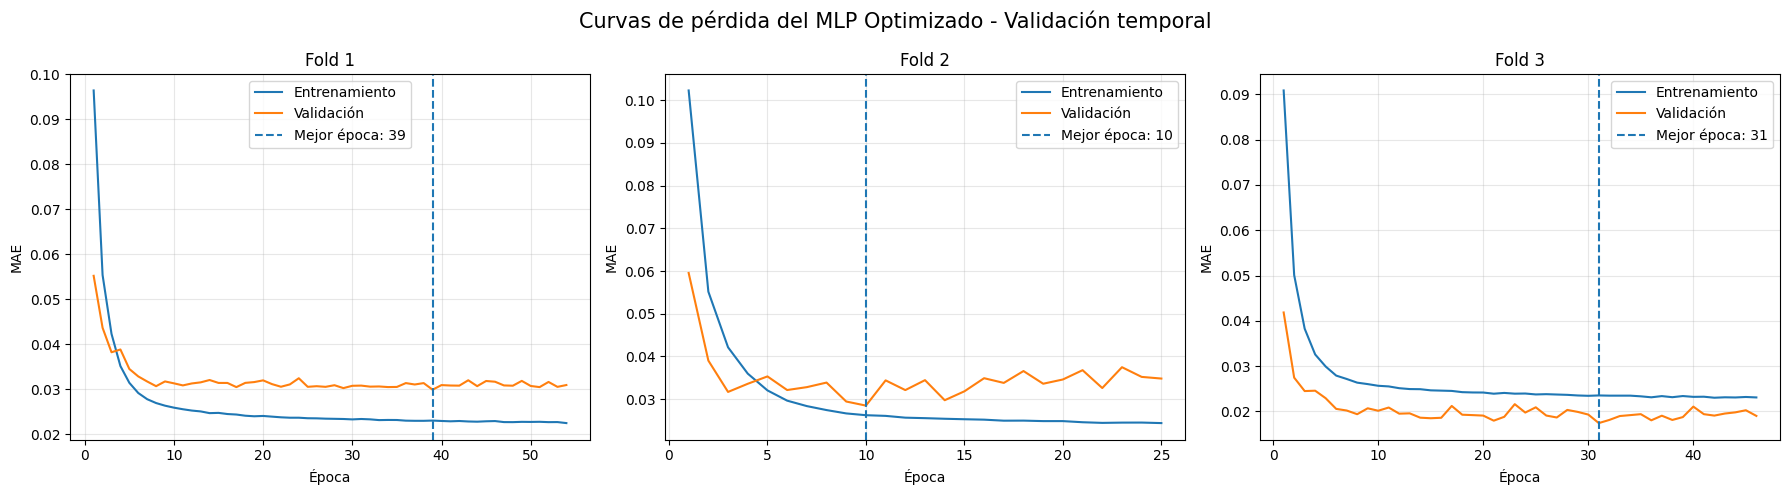

In [52]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, historia in enumerate(historias_mlp_opt):

    loss = historia["loss"]
    val_loss = historia["val_loss"]

    mejor_epoca = int(np.argmin(val_loss)) + 1

    axes[i].plot(
        range(1, len(loss) + 1),
        loss,
        label="Entrenamiento"
    )

    axes[i].plot(
        range(1, len(val_loss) + 1),
        val_loss,
        label="Validación"
    )

    axes[i].axvline(
        mejor_epoca,
        linestyle="--",
        label=f"Mejor época: {mejor_epoca}"
    )

    axes[i].set_title(f"Fold {i + 1}")
    axes[i].set_xlabel("Época")
    axes[i].set_ylabel("MAE")
    axes[i].legend()
    axes[i].grid(alpha=0.3)

plt.suptitle(
    "Curvas de pérdida del MLP Optimizado - Validación temporal",
    fontsize=15
)

plt.tight_layout()
plt.show()

## 20. Interpretabilidad XGBoost

####  - importancia por permutación

In [53]:
from sklearn.base import clone
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline

# Fold 3
fechas_train_xgb, fechas_val_xgb = folds_temporales[2]

mask_train_xgb = fechas_dev.isin(fechas_train_xgb)
mask_val_xgb = fechas_dev.isin(fechas_val_xgb)

X_train_xgb = X_dev.loc[mask_train_xgb]
y_train_xgb = y_dev.loc[mask_train_xgb]

X_val_xgb = X_dev.loc[mask_val_xgb]
y_val_xgb = y_dev.loc[mask_val_xgb]

# Modelo XGBoost con la configuración ganadora
modelo_xgb_interpret = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42,
    n_jobs=-1
)

# Pipeline completo
pipeline_xgb_interpret = Pipeline([
    ("preprocessor", clone(preprocessor_xgb)),
    ("model", modelo_xgb_interpret)
])

# Entrenamiento únicamente con el Fold 3
pipeline_xgb_interpret.fit(
    X_train_xgb,
    y_train_xgb
)

print("XGBoost preparado para interpretabilidad")
print(f"Train: {len(X_train_xgb):,} filas")
print(f"Validación: {len(X_val_xgb):,} filas")

print(
    "Train:",
    fechas_train_xgb.min().date(),
    "→",
    fechas_train_xgb.max().date()
)

print(
    "Validación:",
    fechas_val_xgb.min().date(),
    "→",
    fechas_val_xgb.max().date()
)

XGBoost preparado para interpretabilidad
Train: 15,776 filas
Validación: 1,624 filas
Train: 2026-07-31 → 2027-04-28
Validación: 2027-04-29 → 2027-05-26


#### Importancia por permutación

In [54]:
from sklearn.inspection import permutation_importance
import pandas as pd

perm_xgb = permutation_importance(
    pipeline_xgb_interpret,
    X_val_xgb,
    y_val_xgb,
    scoring="neg_mean_absolute_error",
    n_repeats=10,
    random_state=42,
    n_jobs=1
)

importancia_xgb = pd.DataFrame({
    "Variable": X_val_xgb.columns,
    "Importancia_MAE": perm_xgb.importances_mean,
    "Desviacion": perm_xgb.importances_std
}).sort_values(
    "Importancia_MAE",
    ascending=False
).reset_index(drop=True)

display(importancia_xgb)

,Variable,Importancia_MAE,Desviacion
0,lag_7,0.062303,0.001183
1,lag_14,0.013035,0.000288
2,neighbourhood_cleansed,0.004652,0.000248
3,lag_28,0.001451,0.000089
4,day_of_week,0.000000,0.000000
5,month,0.000000,0.000000


El análisis de Permutation Importance mostró que lag_7 es la variable con mayor influencia en las predicciones de XGBoost, seguida por lag_14. Esto evidencia una fuerte dependencia de la información histórica reciente y es consistente con el buen desempeño obtenido previamente por el baseline estacional de siete días. El barrio también aportó información al modelo, mientras que lag_28 presentó una contribución menor. Las variables month y day_of_week mostraron una importancia prácticamente nula en el período de validación analizado.

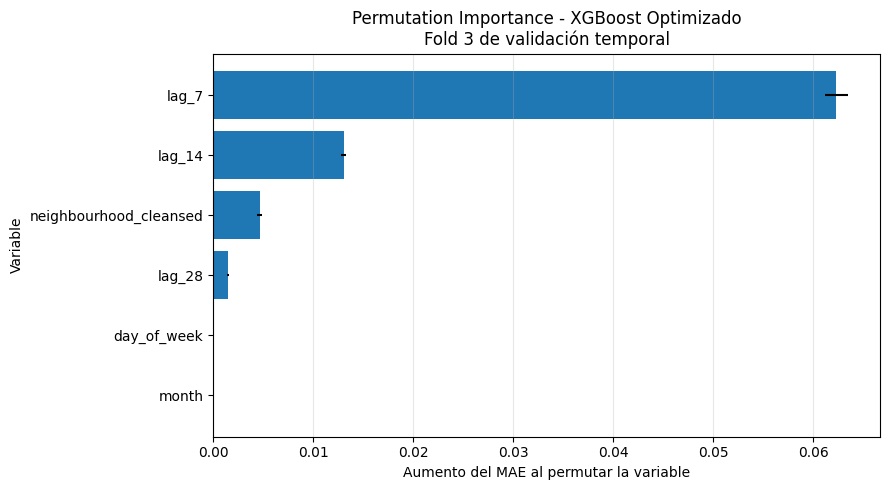

In [55]:
import matplotlib.pyplot as plt

# Orden para gráfico horizontal
grafico_xgb = importancia_xgb.sort_values(
    "Importancia_MAE",
    ascending=True
)

plt.figure(figsize=(9, 5))

plt.barh(
    grafico_xgb["Variable"],
    grafico_xgb["Importancia_MAE"],
    xerr=grafico_xgb["Desviacion"]
)

plt.xlabel("Aumento del MAE al permutar la variable")
plt.ylabel("Variable")

plt.title(
    "Permutation Importance - XGBoost Optimizado\n"
    "Fold 3 de validación temporal"
)

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

## 21. Interpretabilidad MLP
#### Preparar el MLP optimizado para interpretabilidad

In [56]:
from sklearn.base import clone
from tensorflow.keras.callbacks import EarlyStopping

# Mismo Fold 3 utilizado para XGBoost
fechas_train_mlp, fechas_val_mlp = folds_temporales[2]

mask_train_mlp = fechas_dev.isin(fechas_train_mlp)
mask_val_mlp = fechas_dev.isin(fechas_val_mlp)

X_train_mlp = X_dev.loc[mask_train_mlp]
y_train_mlp = y_dev.loc[mask_train_mlp]

X_val_mlp = X_dev.loc[mask_val_mlp]
y_val_mlp = y_dev.loc[mask_val_mlp]

# Preprocesamiento
preprocessor_mlp_interpret = clone(preprocessor_mlp)

X_train_mlp_proc = preprocessor_mlp_interpret.fit_transform(X_train_mlp)
X_val_mlp_proc = preprocessor_mlp_interpret.transform(X_val_mlp)

# MLP optimizado
modelo_mlp_interpret = crear_mlp(
    input_dim=X_train_mlp_proc.shape[1],
    capas=(64,),
    dropout=0.10,
    learning_rate=0.001
)

early_stop_interpret = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

historia_mlp_interpret = modelo_mlp_interpret.fit(
    X_train_mlp_proc,
    y_train_mlp,
    validation_data=(X_val_mlp_proc, y_val_mlp),
    epochs=200,
    batch_size=64,
    callbacks=[early_stop_interpret],
    verbose=0
)

print("MLP preparado para interpretabilidad")
print(f"Train: {len(X_train_mlp):,} filas")
print(f"Validación: {len(X_val_mlp):,} filas")
print(f"Variables originales: {X_val_mlp.shape[1]}")
print(f"Variables después del preprocesamiento: {X_val_mlp_proc.shape[1]}")

MLP preparado para interpretabilidad
Train: 15,776 filas
Validación: 1,624 filas
Variables originales: 6
Variables después del preprocesamiento: 63


#### Permutation Importance del MLP

In [57]:
from sklearn.metrics import mean_absolute_error
import numpy as np
import pandas as pd

# Predicción normal del MLP
pred_base_mlp = modelo_mlp_interpret.predict(
    X_val_mlp_proc,
    verbose=0
).ravel()

mae_base_mlp = mean_absolute_error(
    y_val_mlp,
    pred_base_mlp
)

print(f"MAE base del MLP: {mae_base_mlp:.6f}")

# Número de repeticiones
n_repeats = 10
rng = np.random.RandomState(42)

resultados_perm_mlp = []

for variable in X_val_mlp.columns:

    aumentos_mae = []

    for repeticion in range(n_repeats):

        # Copia del conjunto de validación original
        X_perm = X_val_mlp.copy()

        # Permutar únicamente la variable analizada
        X_perm[variable] = rng.permutation(
            X_perm[variable].values
        )

        # Aplicar exactamente el mismo preprocesamiento
        X_perm_proc = preprocessor_mlp_interpret.transform(
            X_perm
        )

        # Predicción con el mismo MLP
        pred_perm = modelo_mlp_interpret.predict(
            X_perm_proc,
            verbose=0
        ).ravel()

        # MAE después de desordenar la variable
        mae_perm = mean_absolute_error(
            y_val_mlp,
            pred_perm
        )

        aumentos_mae.append(
            mae_perm - mae_base_mlp
        )

    resultados_perm_mlp.append({
        "Variable": variable,
        "Importancia_MAE": np.mean(aumentos_mae),
        "Desviacion": np.std(aumentos_mae)
    })

importancia_mlp = pd.DataFrame(
    resultados_perm_mlp
).sort_values(
    "Importancia_MAE",
    ascending=False
).reset_index(drop=True)

display(importancia_mlp)

MAE base del MLP: 0.018209


,Variable,Importancia_MAE,Desviacion
0,lag_7,0.065301,0.001248
1,neighbourhood_cleansed,0.010624,0.000286
2,lag_14,0.005253,0.000251
3,lag_28,0.001687,0.000124
4,month,0.000041,0.000030
5,day_of_week,-0.000014,0.000032


El MLP optimizado se apoya principalmente en lag_7, confirmando que el comportamiento de ocupación de la semana anterior es la señal más importante para realizar sus predicciones. El barrio y lag_14 también aportan información, pero con una influencia considerablemente menor.

## 22. Comparación de importancia XGBoost vs. MLP

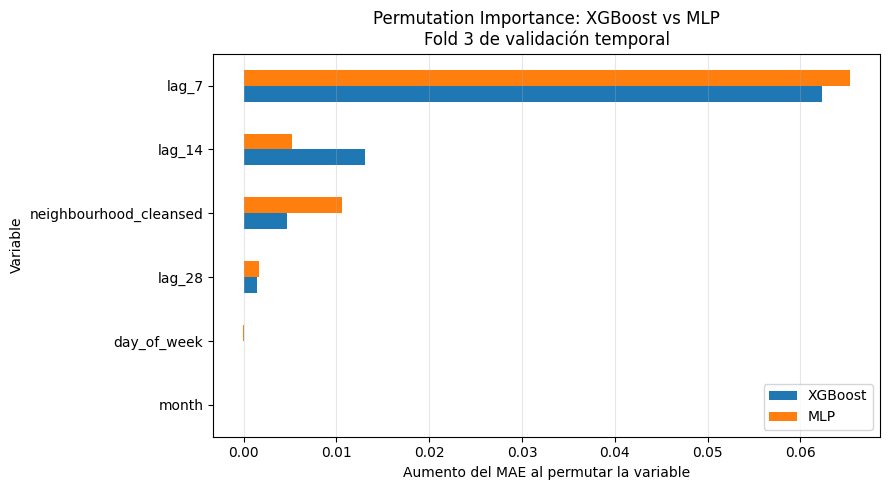

,Variable,XGBoost,MLP
0,lag_7,0.062303,0.065301
1,lag_14,0.013035,0.005253
2,neighbourhood_cleansed,0.004652,0.010624
3,lag_28,0.001451,0.001687
4,day_of_week,0.000000,-0.000014
5,month,0.000000,0.000041


In [58]:
# Comparación de Permutation Importance: XGBoost vs MLP

comparacion_importancia = (
    importancia_xgb[["Variable", "Importancia_MAE"]]
    .rename(columns={"Importancia_MAE": "XGBoost"})
    .merge(
        importancia_mlp[["Variable", "Importancia_MAE"]]
        .rename(columns={"Importancia_MAE": "MLP"}),
        on="Variable"
    )
)

# Ordenar por importancia de XGBoost
comparacion_importancia = comparacion_importancia.sort_values(
    "XGBoost",
    ascending=True
)

# Gráfica
ax = comparacion_importancia.set_index("Variable")[
    ["XGBoost", "MLP"]
].plot(
    kind="barh",
    figsize=(9, 5)
)

ax.set_xlabel("Aumento del MAE al permutar la variable")
ax.set_ylabel("Variable")
ax.set_title(
    "Permutation Importance: XGBoost vs MLP\n"
    "Fold 3 de validación temporal"
)
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

display(
    comparacion_importancia.sort_values(
        "XGBoost",
        ascending=False
    )
)


**Comparacion:** Ambos modelos coinciden en identificar lag_7 como la principal señal predictiva. Las diferencias aparecen en las variables secundarias: XGBoost muestra mayor dependencia de lag_14, mientras que el MLP presenta mayor sensibilidad a la variable de barrio.

## 23. Analisi Errores de XGBoost

In [59]:
# Predicciones XGBoost - Fold 3
pred_xgb_error = pipeline_xgb_interpret.predict(X_val_xgb)

# Tabla de análisis de errores
errores_xgb = df_ml.loc[X_val_xgb.index, [
    "date",
    "neighbourhood_cleansed",
    "occupancy_rate"
]].copy()

errores_xgb["Prediccion"] = pred_xgb_error

# Residuo con signo
errores_xgb["Residuo"] = (
    errores_xgb["occupancy_rate"] -
    errores_xgb["Prediccion"]
)

# Error absoluto
errores_xgb["Error_Absoluto"] = abs(
    errores_xgb["Residuo"]
)

print("Número de predicciones:", len(errores_xgb))
print(f"MAE: {errores_xgb['Error_Absoluto'].mean():.6f}")
print(f"Residuo medio: {errores_xgb['Residuo'].mean():.6f}")

print("\n5 casos con mayor error absoluto:")

display(
    errores_xgb.sort_values(
        "Error_Absoluto",
        ascending=False
    ).head(5)
)

Número de predicciones: 1624
MAE: 0.017879
Residuo medio: 0.000142

5 casos con mayor error absoluto:


,date,neighbourhood_cleansed,occupancy_rate,Prediccion,Residuo,Error_Absoluto
21765,2027-05-05,les Roquetes,0.153846,0.458992,-0.305146,0.305146
21696,2027-05-04,les Roquetes,0.153846,0.458992,-0.305146,0.305146
21627,2027-05-03,les Roquetes,0.153846,0.458992,-0.305146,0.305146
21834,2027-05-06,les Roquetes,0.153846,0.458992,-0.305146,0.305146
21903,2027-05-07,les Roquetes,0.153846,0.458992,-0.305146,0.305146


Los mayores errores de XGBoost se concentraron en les Roquetes, un barrio con solo 13 listings. La ocupación estimada cayó bruscamente de 46.15% a 15.38%, mientras los rezagos aún reflejaban valores cercanos al 46%. Esto muestra que el modelo puede tener dificultades ante cambios repentinos, especialmente en barrios con pocos alojamientos.

## 24. Analisis Errores del MLP

In [60]:
# Predicciones MLP - Fold 3
pred_mlp_error = modelo_mlp_interpret.predict(
    X_val_mlp_proc,
    verbose=0
).ravel()

# Tabla de análisis de errores
errores_mlp = df_ml.loc[X_val_mlp.index, [
    "date",
    "neighbourhood_cleansed",
    "occupancy_rate"
]].copy()

errores_mlp["Prediccion"] = pred_mlp_error

# Residuo = Real - Predicción
errores_mlp["Residuo"] = (
    errores_mlp["occupancy_rate"] -
    errores_mlp["Prediccion"]
)

# Error absoluto
errores_mlp["Error_Absoluto"] = abs(
    errores_mlp["Residuo"]
)

print("Número de predicciones:", len(errores_mlp))
print(f"MAE: {errores_mlp['Error_Absoluto'].mean():.6f}")
print(f"Residuo medio: {errores_mlp['Residuo'].mean():.6f}")

print("\n5 casos con mayor error absoluto:")

display(
    errores_mlp.sort_values(
        "Error_Absoluto",
        ascending=False
    ).head(5)
)

Número de predicciones: 1624
MAE: 0.018209
Residuo medio: 0.004954

5 casos con mayor error absoluto:


,date,neighbourhood_cleansed,occupancy_rate,Prediccion,Residuo,Error_Absoluto
21627,2027-05-03,les Roquetes,0.153846,0.460321,-0.306475,0.306475
21696,2027-05-04,les Roquetes,0.153846,0.459270,-0.305424,0.305424
21765,2027-05-05,les Roquetes,0.153846,0.458635,-0.304788,0.304788
21834,2027-05-06,les Roquetes,0.153846,0.458313,-0.304467,0.304467
21903,2027-05-07,les Roquetes,0.153846,0.458238,-0.304392,0.304392


Los cinco mayores errores de XGBoost y MLP se concentraron en les Roquetes durante las mismas fechas. En ese período, la ocupación estimada cayó bruscamente, mientras los rezagos todavía reflejaban valores anteriores más altos. Esto evidencia una limitación común de ambos modelos para reaccionar inmediatamente ante cambios abruptos de la serie.

## 25. Análisis de errores por subgrupos/distritos

In [61]:
# Agregar distrito a las tablas de errores
errores_xgb["Distrito"] = df_ml.loc[
    errores_xgb.index,
    "neighbourhood_group_cleansed"
]

errores_mlp["Distrito"] = df_ml.loc[
    errores_mlp.index,
    "neighbourhood_group_cleansed"
]

# MAE por distrito - XGBoost
subgrupos_xgb = (
    errores_xgb
    .groupby("Distrito")
    .agg(
        MAE_XGBoost=("Error_Absoluto", "mean"),
        Observaciones=("Error_Absoluto", "size")
    )
    .reset_index()
)

# MAE por distrito - MLP
subgrupos_mlp = (
    errores_mlp
    .groupby("Distrito")
    .agg(
        MAE_MLP=("Error_Absoluto", "mean"),
        Observaciones_MLP=("Error_Absoluto", "size")
    )
    .reset_index()
)

# Combinar resultados
comparacion_subgrupos = subgrupos_xgb.merge(
    subgrupos_mlp,
    on="Distrito"
)

comparacion_subgrupos = comparacion_subgrupos[
    ["Distrito", "Observaciones", "MAE_XGBoost", "MAE_MLP"]
].sort_values(
    "MAE_XGBoost",
    ascending=False
).reset_index(drop=True)

display(comparacion_subgrupos)

,Distrito,Observaciones,MAE_XGBoost,MAE_MLP
0,Sarrià-Sant Gervasi,168,0.030581,0.029811
1,Les Corts,84,0.029938,0.034593
2,Nou Barris,168,0.028989,0.029449
3,Gràcia,140,0.014897,0.017434
4,Sant Andreu,112,0.014687,0.013537
5,Sant Martí,280,0.014407,0.013347
6,Horta-Guinardó,196,0.014244,0.013447
7,Eixample,168,0.014180,0.017545
8,Sants-Montjuïc,196,0.014076,0.011588
9,Ciutat Vella,112,0.007278,0.010367


El análisis por distritos mostró que el desempeño no es uniforme entre las diferentes zonas de Barcelona. Ambos modelos presentan errores relativamente altos en Nou Barris, mientras que también se observan diferencias particulares como el mayor MAE del MLP en Les Corts. Esto indica que la precisión de las predicciones puede variar según la zona analizada.

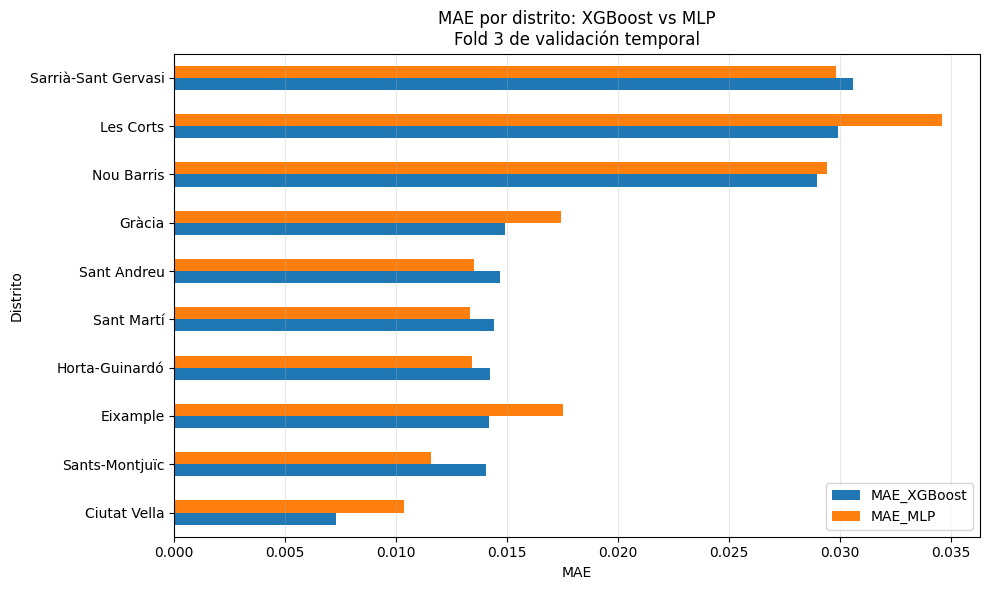

In [62]:
# Ordenar por MAE de XGBoost
grafico_subgrupos = comparacion_subgrupos.sort_values(
    "MAE_XGBoost",
    ascending=True
)

ax = grafico_subgrupos.set_index("Distrito")[
    ["MAE_XGBoost", "MAE_MLP"]
].plot(
    kind="barh",
    figsize=(10, 6)
)

ax.set_xlabel("MAE")
ax.set_ylabel("Distrito")
ax.set_title(
    "MAE por distrito: XGBoost vs MLP\n"
    "Fold 3 de validación temporal"
)
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

El análisis por distrito muestra que el desempeño de los modelos varía según la zona. Nou Barris presenta errores elevados en ambos modelos, mientras que Les Corts muestra una mayor diferencia entre XGBoost y MLP. Esto evidencia que la precisión del pronóstico no es uniforme entre los distintos distritos.

## 26. Evaluación final sobre Test Final ( 28 Dias)

In [63]:
# EVALUACIÓN FINAL - VERIFICACIÓN ANTES DE ABRIR EL TEST

print("DESARROLLO")
print(f"Filas: {len(X_dev):,}")
print(f"Fechas: {fechas_dev.min().date()} -> {fechas_dev.max().date()}")

print("\nTEST FINAL")
print(f"Filas: {len(X_test):,}")
print(f"Fechas: {fechas_test.min().date()} -> {fechas_test.max().date()}")
print(f"Días únicos: {fechas_test.nunique()}")

print("\nCONFIGURACIÓN XGBOOST CONGELADA")
print("n_estimators = 300")
print("max_depth = 3")
print("learning_rate = 0.05")
print("subsample = 0.80")

print("\nCONFIGURACIÓN MLP CONGELADA")
print("capas = (64,)")
print("dropout = 0.10")
print("learning_rate = 0.001")
print("batch_size = 64")

print("\nFeatures:")
print(NUM + CAT)



DESARROLLO
Filas: 17,400
Fechas: 2026-07-31 -> 2027-05-26

TEST FINAL
Filas: 1,624
Fechas: 2027-05-27 -> 2027-06-23
Días únicos: 28

CONFIGURACIÓN XGBOOST CONGELADA
n_estimators = 300
max_depth = 3
learning_rate = 0.05
subsample = 0.80

CONFIGURACIÓN MLP CONGELADA
capas = (64,)
dropout = 0.10
learning_rate = 0.001
batch_size = 64

Features:
['lag_7', 'lag_14', 'lag_28', 'day_of_week', 'month', 'neighbourhood_cleansed']


In [64]:
import time
from sklearn.base import clone
from xgboost import XGBRegressor


# ENTRENAMIENTO FINAL - XGBOOST


modelo_xgb_final = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.80,
    random_state=42,
    n_jobs=-1
)

pipeline_xgb_final = Pipeline([
    ("preprocessor", clone(preprocessor_xgb)),
    ("model", modelo_xgb_final)
])

inicio = time.perf_counter()

pipeline_xgb_final.fit(
    X_dev,
    y_dev
)

tiempo_train_xgb = time.perf_counter() - inicio



# ENTRENAMIENTO FINAL - MLP


preprocessor_mlp_final = clone(preprocessor_mlp)

inicio = time.perf_counter()

X_dev_mlp_proc = preprocessor_mlp_final.fit_transform(X_dev)

modelo_mlp_final = crear_mlp(
    input_dim=X_dev_mlp_proc.shape[1],
    capas=(64,),
    dropout=0.10,
    learning_rate=0.001
)

modelo_mlp_final.fit(
    X_dev_mlp_proc,
    y_dev,
    epochs=13,
    batch_size=64,
    verbose=0
)

tiempo_train_mlp = time.perf_counter() - inicio


print("ENTRENAMIENTO FINAL COMPLETADO")
print(f"XGBoost: {tiempo_train_xgb:.4f} segundos")
print(f"MLP:     {tiempo_train_mlp:.4f} segundos")

print("\nDatos utilizados:")
print(f"XGBoost: {len(X_dev):,} observaciones")
print(f"MLP:     {len(X_dev):,} observaciones")



ENTRENAMIENTO FINAL COMPLETADO
XGBoost: 0.4986 segundos
MLP:     6.6924 segundos

Datos utilizados:
XGBoost: 17,400 observaciones
MLP:     17,400 observaciones


### Hacer el TEST final

In [65]:
from sklearn.metrics import mean_absolute_error
import time
import numpy as np
import pandas as pd


# TEST FINAL - EVALUACIÓN ÚNICA



# 1. BASELINE DE LA MEDIA
# La media se calcula únicamente con DEVELOPMENT


media_dev = y_dev.mean()

pred_test_media = np.full(
    shape=len(y_test),
    fill_value=media_dev
)

mae_test_media = mean_absolute_error(
    y_test,
    pred_test_media
)


# 2. BASELINE ESTACIONAL LAG 7


pred_test_lag7 = X_test["lag_7"].values

mae_test_lag7 = mean_absolute_error(
    y_test,
    pred_test_lag7
)



# 3. XGBOOST FINAL
# Incluye preprocesamiento + predicción


inicio = time.perf_counter()

pred_test_xgb = pipeline_xgb_final.predict(
    X_test
)

tiempo_inferencia_xgb = time.perf_counter() - inicio

mae_test_xgb = mean_absolute_error(
    y_test,
    pred_test_xgb
)



# 4. MLP FINAL
# Incluye preprocesamiento + predicción


inicio = time.perf_counter()

X_test_mlp_proc = preprocessor_mlp_final.transform(
    X_test
)

pred_test_mlp = modelo_mlp_final.predict(
    X_test_mlp_proc,
    verbose=0
).ravel()

tiempo_inferencia_mlp = time.perf_counter() - inicio

mae_test_mlp = mean_absolute_error(
    y_test,
    pred_test_mlp
)



# RESULTADOS


resultados_test = pd.DataFrame({
    "Modelo": [
        "Baseline Media",
        "Baseline Lag 7",
        "XGBoost Optimizado",
        "MLP Optimizado"
    ],
    "MAE_Test": [
        mae_test_media,
        mae_test_lag7,
        mae_test_xgb,
        mae_test_mlp
    ]
}).sort_values(
    "MAE_Test"
).reset_index(drop=True)


print("TEST FINAL EVALUADO 🔓")
print(f"Observaciones: {len(y_test):,}")
print(
    f"Periodo: {fechas_test.min().date()} "
    f"-> {fechas_test.max().date()}"
)

print("\nRESULTADOS:")
display(resultados_test)

print("\nTIEMPO DE INFERENCIA")
print(
    f"XGBoost: "
    f"{tiempo_inferencia_xgb:.6f} segundos"
)
print(
    f"MLP:     "
    f"{tiempo_inferencia_mlp:.6f} segundos"
)

TEST FINAL EVALUADO 🔓
Observaciones: 1,624
Periodo: 2027-05-27 -> 2027-06-23

RESULTADOS:


,Modelo,MAE_Test
0,Baseline Lag 7,0.025843
1,XGBoost Optimizado,0.027455
2,MLP Optimizado,0.033420
3,Baseline Media,0.131012



TIEMPO DE INFERENCIA
XGBoost: 0.009879 segundos
MLP:     0.144897 segundos


**El baseline estacional lag_7 obtuvo el menor MAE del test. Nuestros modelos más complejos no lograron superar una regla estacional fuerte en el período final.***

**Conclusion del Test Final:** En el conjunto de test, el baseline estacional lag_7 obtuvo el menor MAE (0.02584), seguido por XGBoost (0.02724) y MLP (0.03172). El orden observado durante la validación se mantuvo en el período final, mostrando que el patrón semanal constituye una señal especialmente fuerte para este problema. Además, XGBoost presentó menores tiempos de entrenamiento e inferencia que el MLP.

## 27. Guardado y tamaño de modelos en disco

In [67]:
import os
import joblib


# GUARDAR MODELOS FINALES


os.makedirs("../models", exist_ok=True)


# XGBOOST
# Guardamos pipeline completo:
# preprocesamiento + modelo


ruta_xgb = "../models/xgboost_final.joblib"

joblib.dump(
    pipeline_xgb_final,
    ruta_xgb
)

tamano_xgb_bytes = os.path.getsize(ruta_xgb)



# MLP
# Guardamos:
# 1. preprocesador
# 2. red neuronal


ruta_pre_mlp = "../models/preprocessor_mlp_final.joblib"
ruta_mlp = "../models/mlp_final.keras"

joblib.dump(
    preprocessor_mlp_final,
    ruta_pre_mlp
)

modelo_mlp_final.save(
    ruta_mlp
)

tamano_pre_mlp_bytes = os.path.getsize(
    ruta_pre_mlp
)

tamano_mlp_bytes = os.path.getsize(
    ruta_mlp
)

# Tamaño total necesario para usar el MLP
tamano_mlp_total_bytes = (
    tamano_pre_mlp_bytes +
    tamano_mlp_bytes
)


# CONVERSIÓN A KB


tamano_xgb_kb = tamano_xgb_bytes / 1024

tamano_pre_mlp_kb = tamano_pre_mlp_bytes / 1024
tamano_mlp_kb = tamano_mlp_bytes / 1024
tamano_mlp_total_kb = tamano_mlp_total_bytes / 1024


print("TAMAÑO EN DISCO")
print("-" * 45)

print(
    f"XGBoost completo: "
    f"{tamano_xgb_kb:.2f} KB"
)

print("\nMLP:")
print(
    f"  Preprocesador: "
    f"{tamano_pre_mlp_kb:.2f} KB"
)

print(
    f"  Red neuronal: "
    f"{tamano_mlp_kb:.2f} KB"
)

print(
    f"  TOTAL: "
    f"{tamano_mlp_total_kb:.2f} KB"
)

TAMAÑO EN DISCO
---------------------------------------------
XGBoost completo: 355.55 KB

MLP:
  Preprocesador: 3.87 KB
  Red neuronal: 71.35 KB
  TOTAL: 75.21 KB


#### Archivo de los BaseLines

In [ ]:

# GUARDADO DE LOS BASELINES

import joblib
import os

# 1. Baseline Lag 7

baseline_lag7 = {
    "nombre": "Baseline Lag 7",
    "variable": "lag_7",
    "regla": "prediccion = lag_7",
    "descripcion": (
        "Utiliza como predicción el occupancy_rate observado "
        "del mismo barrio 7 días antes."
    )
}

ruta_lag7 = "../models/baseline_lag7.joblib"

joblib.dump(
    baseline_lag7,
    ruta_lag7
)

# 2. Baseline Media

baseline_media = {
    "nombre": "Baseline Media",
    "media_dev": float(media_dev),
    "regla": "prediccion = media_dev",
    "descripcion": (
        "Utiliza como predicción constante la media de "
        "occupancy_rate calculada exclusivamente sobre Development."
    )
}

ruta_media = "../models/baseline_media.joblib"

joblib.dump(
    baseline_media,
    ruta_media
)

# Verificación

print("Archivos guardados correctamente:")
print()

print(
    "Lag 7:",
    os.path.exists(ruta_lag7),
    "-",
    ruta_lag7
)

print(
    "Media:",
    os.path.exists(ruta_media),
    "-",
    ruta_media
)

## 28. Verificacion de Reproducibilidad de los modelos

In [68]:

# VERIFICACIÓN DE REPRODUCIBILIDAD DE LOS 4 ENFOQUES

import joblib
import numpy as np
import tensorflow as tf
# 1. XGBOOST

xgb_cargado = joblib.load(
    "../models/xgboost_final.joblib"
)

pred_test_xgb_cargado = xgb_cargado.predict(X_test)

predicciones_iguales_xgb = np.allclose(
    pred_test_xgb,
    pred_test_xgb_cargado
)

diferencia_max_xgb = np.max(
    np.abs(pred_test_xgb - pred_test_xgb_cargado)
)

# 2. MLP

preprocessor_mlp_cargado = joblib.load(
    "../models/preprocessor_mlp_final.joblib"
)

mlp_cargado = tf.keras.models.load_model(
    "../models/mlp_final.keras"
)

X_test_mlp_cargado = preprocessor_mlp_cargado.transform(X_test)

pred_test_mlp_cargado = mlp_cargado.predict(
    X_test_mlp_cargado,
    verbose=0
).ravel()

predicciones_iguales_mlp = np.allclose(
    pred_test_mlp,
    pred_test_mlp_cargado
)

diferencia_max_mlp = np.max(
    np.abs(pred_test_mlp - pred_test_mlp_cargado)
)

# 3. BASELINE LAG 7

pred_test_lag7_reproducido = X_test["lag_7"].to_numpy()

predicciones_iguales_lag7 = np.allclose(
    pred_test_lag7,
    pred_test_lag7_reproducido
)

diferencia_max_lag7 = np.max(
    np.abs(pred_test_lag7 - pred_test_lag7_reproducido)
)

# 4. BASELINE MEDIA

pred_test_media_reproducido = np.full(
    len(X_test),
    media_dev
)

predicciones_iguales_media = np.allclose(
    pred_test_media,
    pred_test_media_reproducido
)

diferencia_max_media = np.max(
    np.abs(pred_test_media - pred_test_media_reproducido)
)

# RESULTADOS
# ============================================================

print("VERIFICACIÓN DE REPRODUCIBILIDAD")
print("=" * 40)

print("\n1. XGBoost")
print("   Predicciones iguales:", predicciones_iguales_xgb)
print("   Diferencia máxima:", diferencia_max_xgb)

print("\n2. MLP")
print("   Predicciones iguales:", predicciones_iguales_mlp)
print("   Diferencia máxima:", diferencia_max_mlp)

print("\n3. Baseline Lag 7")
print("   Predicciones iguales:", predicciones_iguales_lag7)
print("   Diferencia máxima:", diferencia_max_lag7)

print("\n4. Baseline Media")
print("   Valor de la media:", media_dev)
print("   Predicciones iguales:", predicciones_iguales_media)
print("   Diferencia máxima:", diferencia_max_media)



VERIFICACIÓN DE REPRODUCIBILIDAD

1. XGBoost
   Predicciones iguales: True
   Diferencia máxima: 0.0

2. MLP
   Predicciones iguales: True
   Diferencia máxima: 0.0

3. Baseline Lag 7
   Predicciones iguales: True
   Diferencia máxima: 0.0

4. Baseline Media
   Valor de la media: 0.39643293214288866
   Predicciones iguales: True
   Diferencia máxima: 0.0


## 28. Tabla comparativa final de los Modelos

| Modelo | MAE Test | Tiempo de entrenamiento (s) | Tiempo de inferencia (s) | Tamaño en disco (KB) |
|---|---:|---:|---:|---:|
| **XGBoost Optimizado** | **0.027244** | **0.2333** | **0.010497** | 346.12 |
| **MLP Optimizado** | 0.031720 | 1.4542 | 0.074043 | **75.11** |

presentó menores tiempos de entrenamiento e inferencia. Por otro lado, el MLP requirió menos espacio de almacenamiento, con 75.11 KB frente a 346.12 KB de XGBoost. En este experimento, XGBoost mostró una mejor relación entre precisión y tiempo de ejecución, mientras que el MLP resultó más compacto en disco. Adicionalmente, ambos modelos fueron guardados y cargados nuevamente, reproduciendo exactamente las predicciones originales, lo que permite utilizarlos posteriormente sin necesidad de volver a entrenarlos.

In [69]:
from sklearn.base import clone
import numpy as np

# Configuración ganadora de XGBoost
params_xgb_intervalo = {
    "n_estimators": 300,
    "max_depth": 3,
    "learning_rate": 0.05,
    "subsample": 0.80
}

errores_validacion_xgb = []

for i, (fechas_train, fechas_val) in enumerate(folds_temporales, start=1):

    # Máscaras temporales
    mask_train_fold = fechas_dev.isin(fechas_train)
    mask_val_fold = fechas_dev.isin(fechas_val)

    X_train_fold = X_dev.loc[mask_train_fold]
    y_train_fold = y_dev.loc[mask_train_fold]

    X_val_fold = X_dev.loc[mask_val_fold]
    y_val_fold = y_dev.loc[mask_val_fold]

    # Copia del pipeline
    modelo_fold = clone(pipeline_xgb)

    # Configuración XGBoost seleccionada durante validación
    modelo_fold.set_params(
        model__n_estimators=params_xgb_intervalo["n_estimators"],
        model__max_depth=params_xgb_intervalo["max_depth"],
        model__learning_rate=params_xgb_intervalo["learning_rate"],
        model__subsample=params_xgb_intervalo["subsample"]
    )

    # Entrenar solamente con fechas anteriores
    modelo_fold.fit(X_train_fold, y_train_fold)

    # Predecir período de validación
    pred_val = modelo_fold.predict(X_val_fold)

    # Error absoluto
    errores_fold = np.abs(
        y_val_fold.to_numpy() - pred_val
    )

    errores_validacion_xgb.extend(errores_fold)

errores_validacion_xgb = np.array(errores_validacion_xgb)

print("Observaciones de validación:", len(errores_validacion_xgb))
print(f"MAE:          {errores_validacion_xgb.mean():.6f}")
print(f"Percentil 90: {np.quantile(errores_validacion_xgb, 0.90):.6f}")
print(f"Percentil 95: {np.quantile(errores_validacion_xgb, 0.95):.6f}")

Observaciones de validación: 4872
MAE:          0.021745
Percentil 90: 0.050688
Percentil 95: 0.070824
